<a href="https://colab.research.google.com/github/xiaoyuguo-del/TFM_Seguridad_Vial_Madrid/blob/main/03_Modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


=== TEST DICKEY-FULLER POR DISTRITO ===
(p < 0.05 → serie estacionaria → ARIMA sin diferenciación)
Distrito                     p-valor    Estacionaria
-------------------------------------------------------
ARGANZUELA                    0.0003            ✅ Sí
BARAJAS                       0.0017            ✅ Sí
CARABANCHEL                   0.0000            ✅ Sí
CENTRO                        0.3047           ⚠️ No
CHAMARTÍN                     0.2709           ⚠️ No
CHAMBERÍ                      0.5994           ⚠️ No
CIUDAD LINEAL                 0.0000            ✅ Sí
FUENCARRAL-EL PARDO           0.4508           ⚠️ No
HORTALEZA                     0.0000            ✅ Sí
LATINA                        0.7183           ⚠️ No
MONCLOA-ARAVACA               0.1379           ⚠️ No
MORATALAZ                     0.3238           ⚠️ No
PUENTE DE VALLECAS            0.0412            ✅ Sí
RETIRO                        0.3147           ⚠️ No
SALAMANCA                     0.1328           ⚠️ 

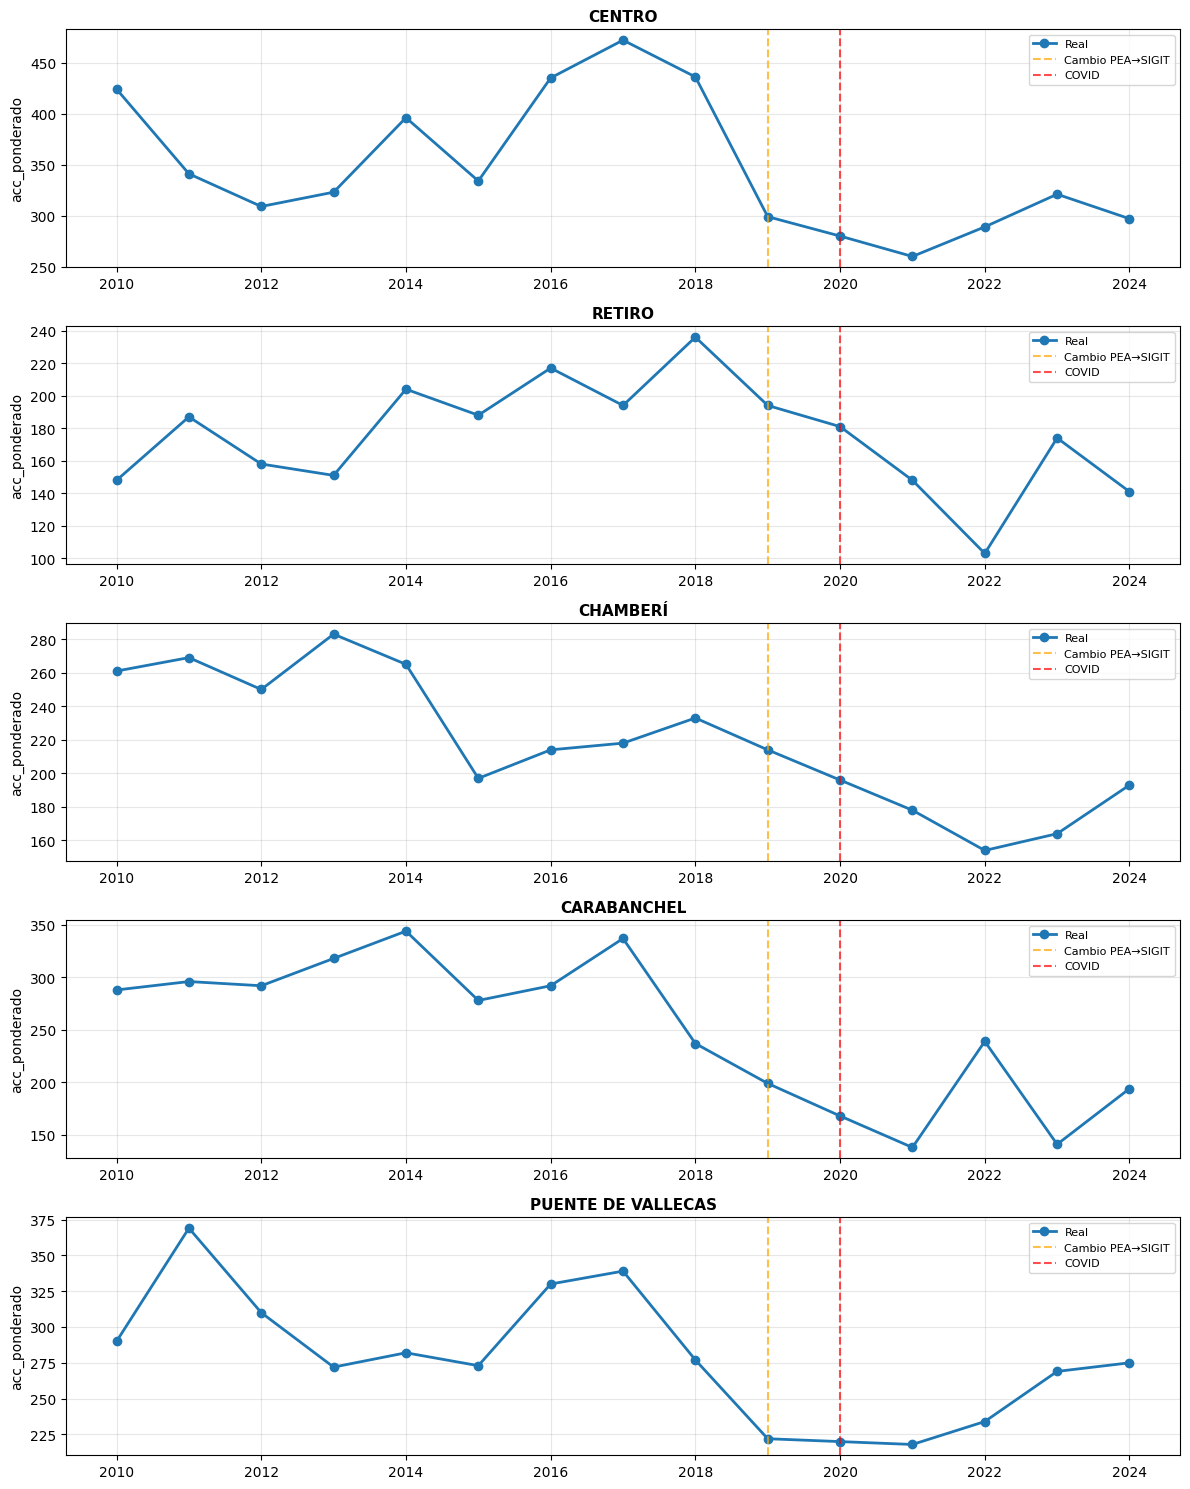

✅ serie_temporal_top5.png guardada


In [ ]:
# ══════════════════════════════════════════════════════════
# CELDA 1 — Análisis exploratorio de la serie temporal
# ══════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

BASE    = '/content/drive/MyDrive/TFM_Seguridad_Vial'
outputs = f'{BASE}/outputs'

serie = pd.read_csv(f'{outputs}/serie_historica_2010_2024_corregida.csv')

# ── Test de estacionariedad (Dickey-Fuller) ───────────────────────────────
# Necesario para ARIMA — la serie debe ser estacionaria o podemos hacerla
# estacionaria con diferenciación

print('=== TEST DICKEY-FULLER POR DISTRITO ===')
print('(p < 0.05 → serie estacionaria → ARIMA sin diferenciación)')
print(f'{"Distrito":<25} {"p-valor":>10} {"Estacionaria":>15}')
print('-' * 55)

resultados_adf = {}
for distrito in sorted(serie['distrito'].unique()):
    s = serie[serie['distrito'] == distrito].sort_values('año')['acc_ponderado'].values
    try:
        result = adfuller(s)
        p_valor = round(result[1], 4)
        estacionaria = '✅ Sí' if p_valor < 0.05 else '⚠️ No'
        resultados_adf[distrito] = p_valor
        print(f'{distrito:<25} {p_valor:>10.4f} {estacionaria:>15}')
    except Exception as e:
        print(f'{distrito:<25} {"ERROR":>10}')

# ── Visualización de la serie para top-5 distritos ────────────────────────
top5 = ['CENTRO', 'RETIRO', 'CHAMBERÍ', 'CARABANCHEL', 'PUENTE DE VALLECAS']

fig, axes = plt.subplots(5, 1, figsize=(12, 15))
for i, distrito in enumerate(top5):
    d = serie[serie['distrito'] == distrito].sort_values('año')
    axes[i].plot(d['año'], d['acc_ponderado'], marker='o', linewidth=2, label='Real')
    axes[i].axvline(x=2019, color='orange', linestyle='--', alpha=0.7, label='Cambio PEA→SIGIT')
    axes[i].axvline(x=2020, color='red', linestyle='--', alpha=0.7, label='COVID')
    axes[i].set_title(distrito, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('acc_ponderado')
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{outputs}/serie_temporal_top5.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ serie_temporal_top5.png guardada')

In [ ]:
# ¿Tienen los datos mensuales 2019-2024 mejor estacionariedad?
from statsmodels.tsa.stattools import adfuller

tabla_mensual = pd.read_csv(f'{outputs}/tabla_mensual_final.csv')

print('=== TEST DICKEY-FULLER — DATOS MENSUALES 2019-2024 ===')
print(f'{"Distrito":<25} {"p-valor":>10} {"Estacionaria":>15}')
print('-' * 55)

for distrito in sorted(tabla_mensual['distrito'].unique()):
    s = (
        tabla_mensual[tabla_mensual['distrito'] == distrito]
        .sort_values(['año','mes'])['acc_ponderado'].values
    )
    try:
        result = adfuller(s)
        p_valor = round(result[1], 4)
        estacionaria = '✅ Sí' if p_valor < 0.05 else '⚠️ No'
        print(f'{distrito:<25} {p_valor:>10.4f} {estacionaria:>15}')
    except Exception as e:
        print(f'{distrito:<25} {"ERROR":>10}')

=== TEST DICKEY-FULLER — DATOS MENSUALES 2019-2024 ===
Distrito                     p-valor    Estacionaria
-------------------------------------------------------
ARGANZUELA                    0.0000            ✅ Sí
BARAJAS                       0.0000            ✅ Sí
CARABANCHEL                   0.0000            ✅ Sí
CENTRO                        0.0000            ✅ Sí
CHAMARTÍN                     0.0000            ✅ Sí
CHAMBERÍ                      0.0000            ✅ Sí
CIUDAD LINEAL                 0.0000            ✅ Sí
FUENCARRAL-EL PARDO           0.0000            ✅ Sí
HORTALEZA                     0.0000            ✅ Sí
LATINA                        0.0000            ✅ Sí
MONCLOA-ARAVACA               0.0000            ✅ Sí
MORATALAZ                     0.0000            ✅ Sí
PUENTE DE VALLECAS            0.7110           ⚠️ No
RETIRO                        0.0000            ✅ Sí
SALAMANCA                     0.0000            ✅ Sí
SAN BLAS-CANILLEJAS           0.5598     

In [ ]:
# ¿Qué meses de 2020 son outliers reales?
tabla_mensual = pd.read_csv(f'{outputs}/tabla_mensual_final.csv')

# Media mensual histórica por mes (usando 2019, 2021, 2022, 2023, 2024)
media_normal = (
    tabla_mensual[tabla_mensual['año'].isin([2019, 2021, 2022, 2023, 2024])]
    .groupby('mes')['acc_ponderado']
    .mean()
    .round(1)
)

# Media mensual de 2020
media_2020 = (
    tabla_mensual[tabla_mensual['año'] == 2020]
    .groupby('mes')['acc_ponderado']
    .mean()
    .round(1)
)

# Comparación
comp = pd.DataFrame({
    'media_normal': media_normal,
    'media_2020':   media_2020
})
comp['diferencia_pct'] = ((comp['media_2020'] - comp['media_normal']) / comp['media_normal'] * 100).round(1)
comp['outlier'] = comp['diferencia_pct'] < -30  # caída > 30% = outlier

print('=== IMPACTO COVID POR MES (2020 vs media normal) ===')
print(comp.to_string())
print(f'\nMeses con caída > 30%: {comp[comp["outlier"]].index.tolist()}')

=== IMPACTO COVID POR MES (2020 vs media normal) ===
     media_normal  media_2020  diferencia_pct  outlier
mes                                                   
1            11.0        15.6            41.8    False
2            10.7        11.6             8.4    False
3            12.4         6.1           -50.8     True
4            13.1         1.8           -86.3     True
5            15.7        10.4           -33.8     True
6            13.6        13.2            -2.9    False
7            12.7        13.7             7.9    False
8             8.6        10.2            18.6    False
9            12.3         9.6           -22.0    False
10           15.5        14.5            -6.5    False
11           14.6        13.0           -11.0    False
12           14.3        14.0            -2.1    False

Meses con caída > 30%: [3, 4, 5]


In [ ]:
# ══════════════════════════════════════════════════════════
# NOTEBOOK: 03_IRP_modelo_predictivo.ipynb
# ══════════════════════════════════════════════════════════

# CELDA 1 — Librerías y carga de datos
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_error

BASE    = '/content/drive/MyDrive/TFM_Seguridad_Vial'
outputs = f'{BASE}/outputs'

# Cargamos serie mensual corregida
serie = pd.read_csv(f'{outputs}/serie_mensual_2010_2024_corregida.csv')

# Creamos columna de fecha para ordenar correctamente
serie['fecha'] = pd.to_datetime(
    serie['año'].astype(str) + '-' + serie['mes'].astype(str).str.zfill(2) + '-01'
)

print(f'Forma: {serie.shape}')
print(f'Distritos: {serie["distrito"].nunique()}')
print(f'Período: {serie["fecha"].min()} → {serie["fecha"].max()}')
print(f'Observaciones por distrito: {serie.groupby("distrito").size().unique()[0]}')
print(f'Nulos: {serie.isnull().sum().sum()}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Forma: (3780, 20)
Distritos: 21
Período: 2010-01-01 00:00:00 → 2024-12-01 00:00:00
Observaciones por distrito: 180
Nulos: 0


In [ ]:
# CELDA 2 — Split temporal 80/20

# 180 meses por distrito
# 80% = 144 meses → 2010-01 a 2021-12
# 20% = 36 meses  → 2022-01 a 2024-12

fecha_corte = pd.Timestamp('2022-01-01')

train = serie[serie['fecha'] < fecha_corte].copy()
test  = serie[serie['fecha'] >= fecha_corte].copy()

print(f'Entrenamiento: {train["fecha"].min().strftime("%Y-%m")} → {train["fecha"].max().strftime("%Y-%m")}')
print(f'  Meses por distrito: {train.groupby("distrito").size().unique()[0]}')
print(f'  Total filas: {len(train)}')

print(f'\nValidación: {test["fecha"].min().strftime("%Y-%m")} → {test["fecha"].max().strftime("%Y-%m")}')
print(f'  Meses por distrito: {test.groupby("distrito").size().unique()[0]}')
print(f'  Total filas: {len(test)}')

# Verificación: 80/20
pct_train = len(train) / len(serie) * 100
pct_test  = len(test)  / len(serie) * 100
print(f'\nSplit real: {pct_train:.1f}% / {pct_test:.1f}%')

Entrenamiento: 2010-01 → 2021-12
  Meses por distrito: 144
  Total filas: 3024

Validación: 2022-01 → 2024-12
  Meses por distrito: 36
  Total filas: 756

Split real: 80.0% / 20.0%


In [ ]:
# CELDA 2B — Test de estacionariedad sobre serie completa 2010-2024

from statsmodels.tsa.stattools import adfuller

print('=== TEST DICKEY-FULLER — SERIE COMPLETA 2010-2024 CORREGIDA ===')
print('(p < 0.05 → serie estacionaria → SARIMA con d=0)')
print(f'{"Distrito":<25} {"p-valor":>10} {"Estacionaria":>15}')
print('-' * 55)

resultados_adf = {}
no_estacionarias = []

for distrito in sorted(serie['distrito'].unique()):
    s = (
        serie[serie['distrito'] == distrito]
        .sort_values('fecha')['acc_ponderado'].values
    )
    result = adfuller(s)
    p_valor = round(result[1], 4)
    estacionaria = '✅ Sí' if p_valor < 0.05 else '⚠️ No'
    resultados_adf[distrito] = p_valor
    if p_valor >= 0.05:
        no_estacionarias.append(distrito)
    print(f'{distrito:<25} {p_valor:>10.4f} {estacionaria:>15}')

print(f'\nEstacionarias: {21 - len(no_estacionarias)}/21')
print(f'No estacionarias: {len(no_estacionarias)}/21')
if no_estacionarias:
    print(f'Distritos no estacionarios: {no_estacionarias}')
    print('\n→ Para estos distritos SARIMA usará d=1 (primera diferencia)')
    print('→ Para los estacionarios SARIMA usará d=0')

=== TEST DICKEY-FULLER — SERIE COMPLETA 2010-2024 CORREGIDA ===
(p < 0.05 → serie estacionaria → SARIMA con d=0)
Distrito                     p-valor    Estacionaria
-------------------------------------------------------
ARGANZUELA                    0.0000            ✅ Sí
BARAJAS                       0.0000            ✅ Sí
CARABANCHEL                   0.4507           ⚠️ No
CENTRO                        0.1361           ⚠️ No
CHAMARTÍN                     0.0008            ✅ Sí
CHAMBERÍ                      0.0010            ✅ Sí
CIUDAD LINEAL                 0.0000            ✅ Sí
FUENCARRAL-EL PARDO           0.2169           ⚠️ No
HORTALEZA                     0.0000            ✅ Sí
LATINA                        0.0000            ✅ Sí
MONCLOA-ARAVACA               0.0098            ✅ Sí
MORATALAZ                     0.0052            ✅ Sí
PUENTE DE VALLECAS            0.0000            ✅ Sí
RETIRO                        0.0000            ✅ Sí
SALAMANCA                     0.0000

In [ ]:
# CELDA 3 — Baseline Naïve Estacional
# Predice que acc_ponderado(mes t) = acc_ponderado(mismo mes, año anterior)
# Es el punto de referencia mínimo — cualquier modelo debe superarlo

predicciones_naive = []

for distrito in sorted(serie['distrito'].unique()):
    d_test = test[test['distrito'] == distrito].sort_values('fecha')

    for _, row in d_test.iterrows():
        mismo_mes_año_anterior = serie[
            (serie['distrito'] == distrito) &
            (serie['año'] == row['año'] - 1) &
            (serie['mes'] == row['mes'])
        ]['acc_ponderado'].values

        pred = mismo_mes_año_anterior[0] if len(mismo_mes_año_anterior) > 0 else np.nan
        predicciones_naive.append({
            'distrito':   distrito,
            'fecha':      row['fecha'],
            'año':        row['año'],
            'mes':        row['mes'],
            'real':       row['acc_ponderado'],
            'pred_naive': pred
        })

df_naive = pd.DataFrame(predicciones_naive).dropna()

# Métricas globales
rmse_naive = np.sqrt(mean_squared_error(df_naive['real'], df_naive['pred_naive']))
mae_naive  = mean_absolute_error(df_naive['real'], df_naive['pred_naive'])

print('=== BASELINE NAÏVE ESTACIONAL ===')
print(f'RMSE: {rmse_naive:.3f}')
print(f'MAE:  {mae_naive:.3f}')
print(f'\nInterpretación: el modelo naïve se equivoca en media')
print(f'{mae_naive:.1f} accidentes ponderados por distrito y mes')

# Métricas por distrito
print('\n=== RMSE POR DISTRITO ===')
rmse_distritos_naive = {}
for distrito in sorted(df_naive['distrito'].unique()):
    d = df_naive[df_naive['distrito'] == distrito]
    rmse = np.sqrt(mean_squared_error(d['real'], d['pred_naive']))
    mae  = mean_absolute_error(d['real'], d['pred_naive'])
    rmse_distritos_naive[distrito] = rmse
    print(f'{distrito:<25}: RMSE={rmse:.2f}  MAE={mae:.2f}')

print(f'\nRMSE medio por distrito: {np.mean(list(rmse_distritos_naive.values())):.3f}')

=== BASELINE NAÏVE ESTACIONAL ===
RMSE: 10.414
MAE:  7.946

Interpretación: el modelo naïve se equivoca en media
7.9 accidentes ponderados por distrito y mes

=== RMSE POR DISTRITO ===
ARGANZUELA               : RMSE=8.98  MAE=7.36
BARAJAS                  : RMSE=6.83  MAE=5.14
CARABANCHEL              : RMSE=10.74  MAE=8.22
CENTRO                   : RMSE=13.34  MAE=10.64
CHAMARTÍN                : RMSE=11.06  MAE=9.22
CHAMBERÍ                 : RMSE=11.64  MAE=8.69
CIUDAD LINEAL            : RMSE=13.10  MAE=10.06
FUENCARRAL-EL PARDO      : RMSE=10.92  MAE=8.58
HORTALEZA                : RMSE=10.21  MAE=8.03
LATINA                   : RMSE=9.53  MAE=6.50
MONCLOA-ARAVACA          : RMSE=11.82  MAE=9.69
MORATALAZ                : RMSE=7.90  MAE=5.11
PUENTE DE VALLECAS       : RMSE=13.13  MAE=11.19
RETIRO                   : RMSE=11.88  MAE=9.14
SALAMANCA                : RMSE=12.88  MAE=10.39
SAN BLAS-CANILLEJAS      : RMSE=10.58  MAE=7.72
TETUÁN                   : RMSE=9.48  MAE=7.83


In [ ]:
# CELDA 4 — SARIMA por distrito
# Un modelo SARIMA independiente por cada uno de los 21 distritos
# Parámetros:
#   p=1, d=auto (0 si estacionario, 1 si no), q=1  → parte no estacional
#   P=1, D=1, Q=1, s=12                             → parte estacional (anual)
# Justificación: s=12 porque los datos son mensuales con estacionalidad anual
# Referencia: Box, Jenkins, Reinsel & Ljung (2015), Time Series Analysis

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Distritos no estacionarios → d=1
no_estacionarios = ['CENTRO', 'FUENCARRAL-EL PARDO', 'TETUÁN']

predicciones_sarima = []
modelos_sarima = {}
metricas_sarima = {}

print('Entrenando SARIMA por distrito...')
print(f'{"Distrito":<25} {"RMSE":>8} {"MAE":>8} {"vs Naïve":>10}')
print('-' * 55)

for distrito in sorted(serie['distrito'].unique()):
    # Serie de entrenamiento
    s_train = (
        train[train['distrito'] == distrito]
        .sort_values('fecha')
        .set_index('fecha')['acc_ponderado']
    )

    # Parámetros según estacionariedad
    d = 1 if distrito in no_estacionarios else 0

    try:
        modelo = SARIMAX(
            s_train,
            order=(1, d, 1),
            seasonal_order=(1, 1, 1, 12),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        resultado = modelo.fit(disp=False)
        modelos_sarima[distrito] = resultado

        # Predicciones para el período de test (36 meses)
        pred = resultado.forecast(steps=36)
        pred = np.maximum(pred, 0)  # no puede haber accidentes negativos

        d_test = test[test['distrito'] == distrito].sort_values('fecha')

        for i, (_, row) in enumerate(d_test.iterrows()):
            predicciones_sarima.append({
                'distrito':    distrito,
                'fecha':       row['fecha'],
                'año':         row['año'],
                'mes':         row['mes'],
                'real':        row['acc_ponderado'],
                'pred_sarima': pred.iloc[i] if i < len(pred) else np.nan
            })

        # Métricas
        reales = d_test['acc_ponderado'].values
        preds  = pred.values[:len(reales)]
        rmse   = np.sqrt(mean_squared_error(reales, preds))
        mae    = mean_absolute_error(reales, preds)
        metricas_sarima[distrito] = {'rmse': rmse, 'mae': mae}

        vs_naive = rmse_distritos_naive.get(distrito, np.nan)
        mejora = '✅' if rmse < vs_naive else '⚠️'
        print(f'{distrito:<25} {rmse:>8.2f} {mae:>8.2f} {mejora} ({rmse/vs_naive*100:.0f}% del naïve)')

    except Exception as e:
        print(f'{distrito:<25} ERROR: {e}')

df_sarima = pd.DataFrame(predicciones_sarima).dropna()

# Métricas globales
rmse_sarima = np.sqrt(mean_squared_error(df_sarima['real'], df_sarima['pred_sarima']))
mae_sarima  = mean_absolute_error(df_sarima['real'], df_sarima['pred_sarima'])

print(f'\n=== RESUMEN SARIMA vs NAÏVE ===')
print(f'{"":25} {"RMSE":>8} {"MAE":>8}')
print(f'{"Naïve estacional":<25} {rmse_naive:>8.3f} {mae_naive:>8.3f}')
print(f'{"SARIMA":<25} {rmse_sarima:>8.3f} {mae_sarima:>8.3f}')
mejora_pct = (1 - rmse_sarima/rmse_naive) * 100
print(f'\nMejora SARIMA vs Naïve: {mejora_pct:.1f}%')
if mejora_pct > 0:
    print('✅ SARIMA supera al baseline')
else:
    print('⚠️ SARIMA no supera al baseline — revisar parámetros')

Entrenando SARIMA por distrito...
Distrito                      RMSE      MAE   vs Naïve
-------------------------------------------------------
ARGANZUELA                    8.04     6.49 ✅ (90% del naïve)
BARAJAS                       5.42     4.72 ✅ (79% del naïve)
CARABANCHEL                   7.54     5.79 ✅ (70% del naïve)
CENTRO                       10.84     9.04 ✅ (81% del naïve)
CHAMARTÍN                     9.06     7.77 ✅ (82% del naïve)
CHAMBERÍ                     10.06     8.63 ✅ (86% del naïve)
CIUDAD LINEAL                 8.87     7.01 ✅ (68% del naïve)
FUENCARRAL-EL PARDO           9.35     7.05 ✅ (86% del naïve)
HORTALEZA                     7.77     5.68 ✅ (76% del naïve)
LATINA                        8.30     6.77 ✅ (87% del naïve)
MONCLOA-ARAVACA               9.98     8.01 ✅ (84% del naïve)
MORATALAZ                     5.46     3.96 ✅ (69% del naïve)
PUENTE DE VALLECAS           10.89     8.56 ✅ (83% del naïve)
RETIRO                        9.40     8.34 ✅ (79

In [ ]:
# CELDA 4B — Modelo 2: SARIMA con variable exógena (ARIMAX)
# Añade cambio_estructura como variable exógena para controlar
# el salto PEA→SIGIT de 2019
# Compara con SARIMA puro para ver si la variable exógena aporta

predicciones_arimax = []
metricas_arimax = {}

print('Entrenando ARIMAX por distrito...')
print(f'{"Distrito":<25} {"RMSE":>8} {"MAE":>8} {"vs Naïve":>10} {"vs SARIMA":>10}')
print('-' * 65)

for distrito in sorted(serie['distrito'].unique()):
    s_train = (
        train[train['distrito'] == distrito]
        .sort_values('fecha')  # ← orden garantizado
        .set_index('fecha')
    )
    exog_train = s_train[['cambio_estructura']]
    y_train_d  = s_train['acc_ponderado']

    d_test_full = (
        test[test['distrito'] == distrito]
        .sort_values('fecha')  # ← orden garantizado
    )
    exog_test = d_test_full[['cambio_estructura']].values

    d = 1 if distrito in no_estacionarios else 0

    try:
        modelo = SARIMAX(
            y_train_d,
            exog=exog_train,
            order=(1, d, 1),
            seasonal_order=(1, 1, 1, 12),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        resultado = modelo.fit(disp=False)

        pred = resultado.forecast(steps=36, exog=exog_test)
        pred = np.maximum(pred, 0)

        reales = d_test_full['acc_ponderado'].values
        preds  = pred.values[:len(reales)]
        rmse   = np.sqrt(mean_squared_error(reales, preds))
        mae    = mean_absolute_error(reales, preds)
        metricas_arimax[distrito] = {'rmse': rmse, 'mae': mae}

        for i, (_, row) in enumerate(d_test_full.iterrows()):
            predicciones_arimax.append({
                'distrito':    distrito,
                'fecha':       row['fecha'],
                'año':         row['año'],
                'mes':         row['mes'],
                'real':        row['acc_ponderado'],
                'pred_arimax': pred.iloc[i] if i < len(pred) else np.nan
            })

        vs_naive  = rmse_distritos_naive.get(distrito, np.nan)
        vs_sarima = metricas_sarima[distrito]['rmse']
        mejor_naive  = '✅' if rmse < vs_naive  else '⚠️'
        mejor_sarima = '✅' if rmse < vs_sarima else '⚠️'
        print(f'{distrito:<25} {rmse:>8.2f} {mae:>8.2f} {mejor_naive} ({rmse/vs_naive*100:.0f}%)  {mejor_sarima} ({rmse/vs_sarima*100:.0f}%)')

    except Exception as e:
        print(f'{distrito:<25} ERROR: {e}')

df_arimax = pd.DataFrame(predicciones_arimax).dropna()
rmse_arimax = np.sqrt(mean_squared_error(df_arimax['real'], df_arimax['pred_arimax']))
mae_arimax  = mean_absolute_error(df_arimax['real'], df_arimax['pred_arimax'])

print(f'\n=== RESUMEN COMPARATIVO ===')
print(f'{"":25} {"RMSE":>8} {"MAE":>8}')
print(f'{"Naïve estacional":<25} {rmse_naive:>8.3f} {mae_naive:>8.3f}')
print(f'{"SARIMA":<25} {rmse_sarima:>8.3f} {mae_sarima:>8.3f}')
print(f'{"ARIMAX":<25} {rmse_arimax:>8.3f} {mae_arimax:>8.3f}')

Entrenando ARIMAX por distrito...
Distrito                      RMSE      MAE   vs Naïve  vs SARIMA
-----------------------------------------------------------------
ARGANZUELA                    8.55     6.95 ✅ (95%)  ⚠️ (106%)
BARAJAS                       5.40     4.28 ✅ (79%)  ✅ (99%)
CARABANCHEL                   8.18     6.04 ✅ (76%)  ⚠️ (109%)
CENTRO                       10.02     8.56 ✅ (75%)  ✅ (92%)
CHAMARTÍN                    13.87    11.70 ⚠️ (125%)  ⚠️ (153%)
CHAMBERÍ                      9.05     7.51 ✅ (78%)  ✅ (90%)
CIUDAD LINEAL                 8.56     6.87 ✅ (65%)  ✅ (96%)
FUENCARRAL-EL PARDO           8.74     7.29 ✅ (80%)  ✅ (93%)
HORTALEZA                     7.86     5.61 ✅ (77%)  ⚠️ (101%)
LATINA                        8.30     6.64 ✅ (87%)  ⚠️ (100%)
MONCLOA-ARAVACA              10.09     7.72 ✅ (85%)  ⚠️ (101%)
MORATALAZ                     5.30     3.44 ✅ (67%)  ✅ (97%)
PUENTE DE VALLECAS           10.82     8.47 ✅ (82%)  ✅ (99%)
RETIRO                     

In [ ]:
# CELDA 4C — Modelo 3: Ridge global con efectos fijos
# Un único modelo para todos los distritos
# Features: lag_1, lag_12, tendencia_3m, cambio_estructura,
#           covid_imputado, dummies de mes, efectos fijos por distrito
# Referencia: Hoerl & Kennard (1970), Ridge Regression

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import re

def crear_features_panel(df):
    """
    Crea features de lag y tendencia para regresión de panel.
    Los lags usan shift() que garantiza que no hay data leakage:
    lag_1 en fecha t = valor en t-1 (siempre anterior al punto de predicción).
    El split temporal se aplica DESPUÉS de calcular los features.
    """
    df = df.sort_values(['distrito', 'fecha']).copy()

    # Lags autorregresivos
    df['lag_1']  = df.groupby('distrito')['acc_ponderado'].shift(1)
    df['lag_12'] = df.groupby('distrito')['acc_ponderado'].shift(12)

    # Tendencia últimos 3 meses (usando solo datos anteriores)
    df['tendencia_3m'] = df.groupby('distrito')['acc_ponderado'].transform(
        lambda x: x.shift(1).rolling(3).apply(
            lambda y: np.polyfit(range(len(y)), y, 1)[0] if len(y) == 3 else np.nan
        )
    )

    # Estacionalidad mensual (dummies)
    for m in range(1, 13):
        df[f'mes_{m}'] = (df['mes'] == m).astype(int)

    # Efectos fijos por distrito (dummies)
    for d in df['distrito'].unique():
        col = f'dist_{re.sub("[^a-zA-Z0-9]", "_", d)}'
        df[col] = (df['distrito'] == d).astype(int)

    return df

# Calculamos features sobre serie completa (shift garantiza no leakage)
serie_features = crear_features_panel(serie)

feature_cols = (
    ['lag_1', 'lag_12', 'tendencia_3m', 'cambio_estructura', 'covid_imputado'] +
    [f'mes_{m}' for m in range(2, 13)] +
    [c for c in serie_features.columns if c.startswith('dist_')]
)

# Split temporal — después de calcular features
train_p = serie_features[serie_features['fecha'] < fecha_corte].dropna(subset=feature_cols)
test_p  = serie_features[serie_features['fecha'] >= fecha_corte].dropna(subset=feature_cols)

X_train = train_p[feature_cols].values
y_train = train_p['acc_ponderado'].values
X_test  = test_p[feature_cols].values
y_test  = test_p['acc_ponderado'].values

# Escalado
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Ridge alpha=1
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)
y_pred_ridge = np.maximum(ridge.predict(X_test_sc), 0)
rmse_ridge   = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae_ridge    = mean_absolute_error(y_test, y_pred_ridge)

print('=== RIDGE REGRESSION (Panel con efectos fijos) ===')
print(f'Observaciones train: {len(X_train)}')
print(f'Observaciones test:  {len(X_test)}')
print(f'Features:            {len(feature_cols)}')
print(f'RMSE: {rmse_ridge:.3f}')
print(f'MAE:  {mae_ridge:.3f}')

print(f'\n=== RESUMEN COMPARATIVO ===')
print(f'{"":25} {"RMSE":>8} {"MAE":>8} {"Mejora vs Naïve":>16}')
print(f'{"Naïve estacional":<25} {rmse_naive:>8.3f} {mae_naive:>8.3f} {"—":>16}')
print(f'{"SARIMA":<25} {rmse_sarima:>8.3f} {mae_sarima:>8.3f} {(1-rmse_sarima/rmse_naive)*100:>15.1f}%')
print(f'{"ARIMAX":<25} {rmse_arimax:>8.3f} {mae_arimax:>8.3f} {(1-rmse_arimax/rmse_naive)*100:>15.1f}%')
print(f'{"Ridge global alpha=1":<25} {rmse_ridge:>8.3f} {mae_ridge:>8.3f} {(1-rmse_ridge/rmse_naive)*100:>15.1f}%')

=== RIDGE REGRESSION (Panel con efectos fijos) ===
Observaciones train: 2772
Observaciones test:  756
Features:            37
RMSE: 7.601
MAE:  5.969

=== RESUMEN COMPARATIVO ===
                              RMSE      MAE  Mejora vs Naïve
Naïve estacional            10.414    7.946                —
SARIMA                       8.350    6.558            19.8%
ARIMAX                       8.438    6.485            19.0%
Ridge global alpha=1         7.601    5.969            27.0%


=== DIAGNÓSTICO OVERFITTING/UNDERFITTING ===
                         RMSE      MAE
Train (2010-2021)       8.658    6.697
Test  (2022-2024)       7.601    5.969

Ratio RMSE test/train: 0.878
✅ Sin overfitting — modelo bien generalizado (ratio < 1.2)


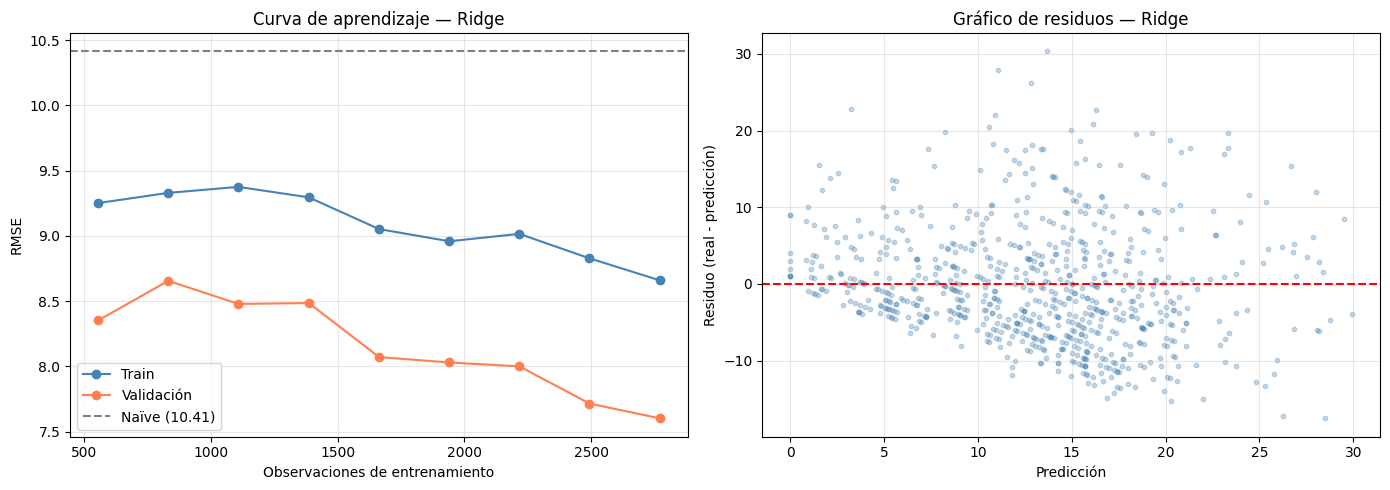

✅ ridge_diagnostico.png guardado

=== VALIDACIÓN CRUZADA TEMPORAL (5 folds) ===
  Fold 1: RMSE = 10.239
  Fold 2: RMSE = 9.806
  Fold 3: RMSE = 9.689
  Fold 4: RMSE = 9.598
  Fold 5: RMSE = 10.097

RMSE CV medio:  9.886
RMSE CV std:    0.244
RMSE test real: 7.601
⚠️ Diferencia entre CV y test — posible varianza alta


In [ ]:
# CELDA 4D — Diagnóstico overfitting/underfitting

from sklearn.model_selection import TimeSeriesSplit

# ── 1. Comparación RMSE train vs test ─────────────────────────────────────
y_pred_train = np.maximum(ridge.predict(X_train_sc), 0)
rmse_train   = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_train    = mean_absolute_error(y_train, y_pred_train)

print('=== DIAGNÓSTICO OVERFITTING/UNDERFITTING ===')
print(f'{"":20} {"RMSE":>8} {"MAE":>8}')
print(f'{"Train (2010-2021)":<20} {rmse_train:>8.3f} {mae_train:>8.3f}')
print(f'{"Test  (2022-2024)":<20} {rmse_ridge:>8.3f} {mae_ridge:>8.3f}')
ratio = rmse_ridge / rmse_train
print(f'\nRatio RMSE test/train: {ratio:.3f}')
if ratio < 1.2:
    print('✅ Sin overfitting — modelo bien generalizado (ratio < 1.2)')
elif ratio < 1.5:
    print('⚠️ Overfitting leve — ratio entre 1.2 y 1.5')
else:
    print('❌ Overfitting severo — ratio > 1.5')

# ── 2. Curva de aprendizaje ───────────────────────────────────────────────
train_sizes      = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
rmse_train_curve = []
rmse_val_curve   = []

for size in train_sizes:
    n     = int(len(X_train_sc) * size)
    X_sub = X_train_sc[:n]
    y_sub = y_train[:n]

    ridge_temp = Ridge(alpha=1.0)
    ridge_temp.fit(X_sub, y_sub)

    pred_tr = np.maximum(ridge_temp.predict(X_sub), 0)
    pred_te = np.maximum(ridge_temp.predict(X_test_sc), 0)

    rmse_train_curve.append(np.sqrt(mean_squared_error(y_sub, pred_tr)))
    rmse_val_curve.append(np.sqrt(mean_squared_error(y_test, pred_te)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
n_samples = [int(len(X_train_sc) * s) for s in train_sizes]
ax.plot(n_samples, rmse_train_curve, 'o-', label='Train',      color='steelblue')
ax.plot(n_samples, rmse_val_curve,   'o-', label='Validación', color='coral')
ax.axhline(rmse_naive, color='gray', linestyle='--', label=f'Naïve ({rmse_naive:.2f})')
ax.set_xlabel('Observaciones de entrenamiento')
ax.set_ylabel('RMSE')
ax.set_title('Curva de aprendizaje — Ridge')
ax.legend()
ax.grid(alpha=0.3)

ax2 = axes[1]
residuos = y_test - y_pred_ridge
ax2.scatter(y_pred_ridge, residuos, alpha=0.3, color='steelblue', s=10)
ax2.axhline(0, color='red', linestyle='--')
ax2.set_xlabel('Predicción')
ax2.set_ylabel('Residuo (real - predicción)')
ax2.set_title('Gráfico de residuos — Ridge')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{outputs}/ridge_diagnostico.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ ridge_diagnostico.png guardado')

# ── 3. Validación cruzada temporal (TimeSeriesSplit) ──────────────────────
# Corrección: usa X_train_sc directamente sin condición sobre X_full_sc
tscv    = TimeSeriesSplit(n_splits=5)
rmse_cv = []

print('\n=== VALIDACIÓN CRUZADA TEMPORAL (5 folds) ===')
for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_sc)):
    X_tr  = X_train_sc[tr_idx]
    y_tr  = y_train[tr_idx]
    X_val = X_train_sc[val_idx]
    y_val = y_train[val_idx]

    r = Ridge(alpha=1.0)
    r.fit(X_tr, y_tr)
    pred_val  = np.maximum(r.predict(X_val), 0)
    rmse_fold = np.sqrt(mean_squared_error(y_val, pred_val))
    rmse_cv.append(rmse_fold)
    print(f'  Fold {fold+1}: RMSE = {rmse_fold:.3f}')

print(f'\nRMSE CV medio:  {np.mean(rmse_cv):.3f}')
print(f'RMSE CV std:    {np.std(rmse_cv):.3f}')
print(f'RMSE test real: {rmse_ridge:.3f}')

if abs(np.mean(rmse_cv) - rmse_ridge) < np.std(rmse_cv) * 2:
    print('✅ RMSE test consistente con validación cruzada')
else:
    print('⚠️ Diferencia entre CV y test — posible varianza alta')

In [ ]:
# Análisis profundo del target
print('=== ESTADÍSTICAS DEL TARGET (test 2022-2024) ===')
print(test['acc_ponderado'].describe().round(2))

print('\n=== DISTRIBUCIÓN POR DISTRITO ===')
print(test.groupby('distrito')['acc_ponderado'].agg(['mean','std','min','max']).round(2).to_string())

print('\n=== % DE MESES CON acc_ponderado = 0 ===')
pct_ceros = (test['acc_ponderado'] == 0).mean() * 100
print(f'{pct_ceros:.1f}% de observaciones tienen acc_ponderado = 0')

print('\n=== DISTRIBUCIÓN DE VALORES ===')
print(pd.cut(test['acc_ponderado'],
             bins=[0,1,5,10,20,50,100,999],
             labels=['0','1-4','5-9','10-19','20-49','50-99','100+']).value_counts().sort_index())

=== ESTADÍSTICAS DEL TARGET (test 2022-2024) ===
count    756.00
mean      12.85
std        8.93
min        0.00
25%        6.00
50%       11.00
75%       17.00
max       44.00
Name: acc_ponderado, dtype: float64

=== DISTRIBUCIÓN POR DISTRITO ===
                      mean    std  min   max
distrito                                    
ARGANZUELA           12.97   6.38  3.0  26.0
BARAJAS               5.03   4.74  0.0  19.0
CARABANCHEL          15.94   7.22  4.0  38.0
CENTRO               25.19  10.02  8.0  43.0
CHAMARTÍN            13.17   7.40  3.0  35.0
CHAMBERÍ             14.19   9.32  2.0  39.0
CIUDAD LINEAL        13.42   7.97  3.0  34.0
FUENCARRAL-EL PARDO  15.06   8.57  2.0  39.0
HORTALEZA            13.11   8.71  1.0  44.0
LATINA               15.72   7.76  5.0  33.0
MONCLOA-ARAVACA      14.89   8.49  2.0  33.0
MORATALAZ             4.75   5.43  0.0  26.0
PUENTE DE VALLECAS   21.61   9.42  4.0  41.0
RETIRO               11.61   8.85  1.0  39.0
SALAMANCA            15.92   8.3

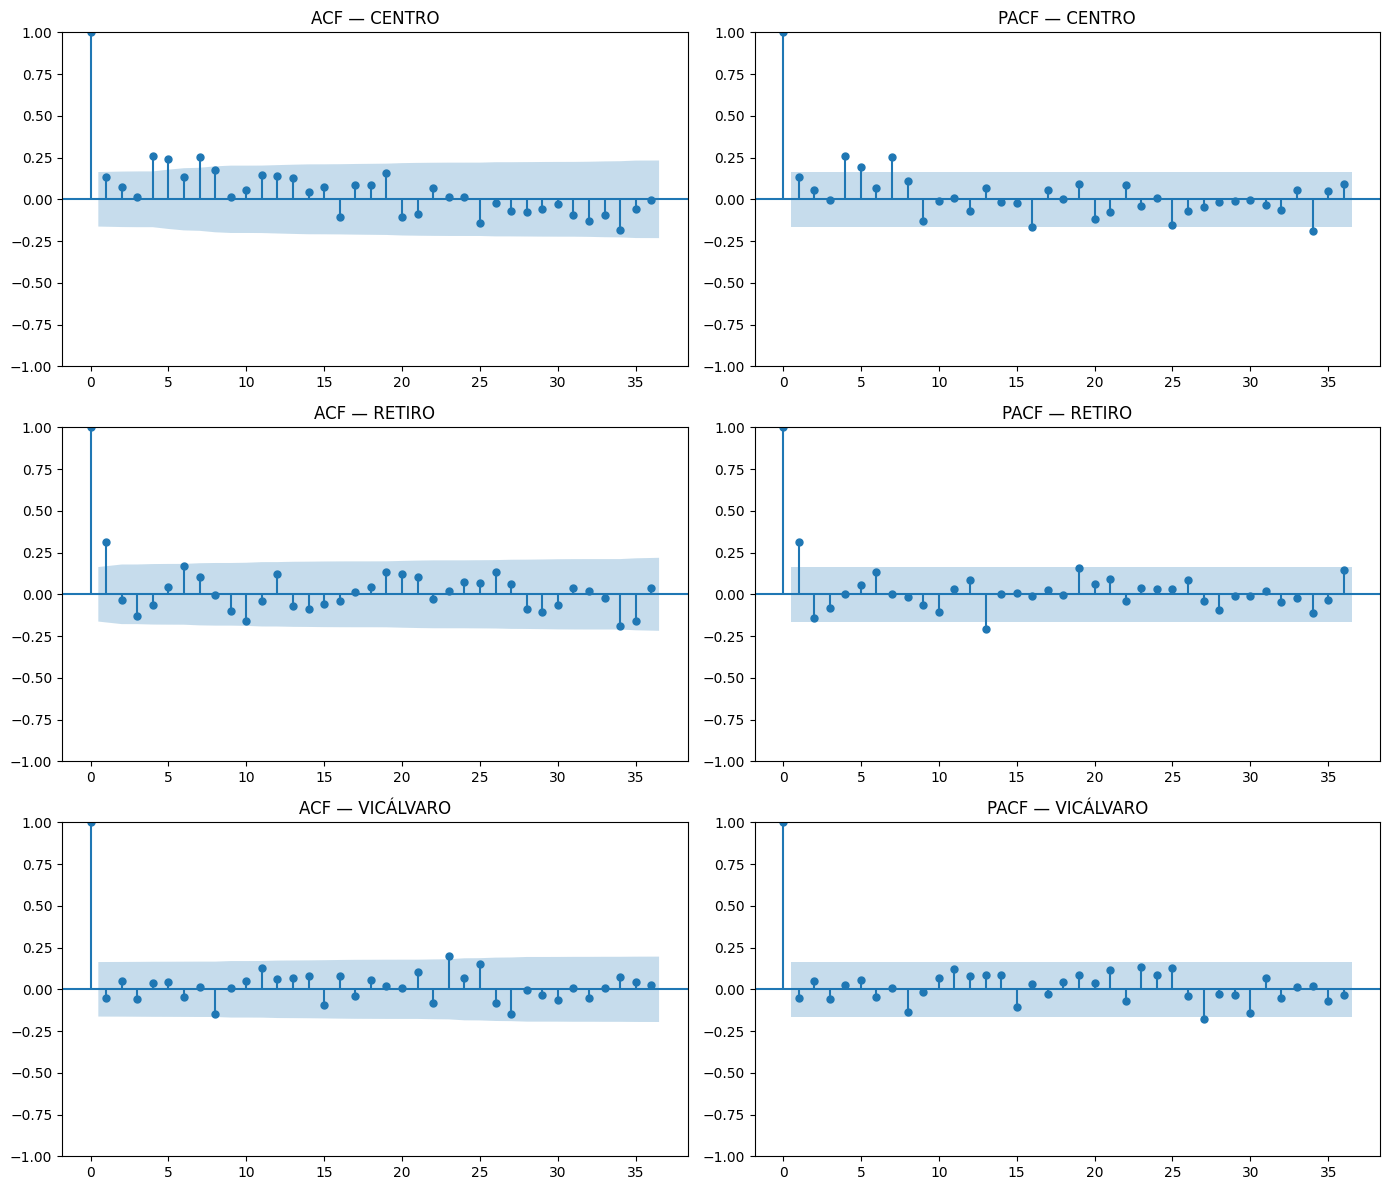

✅ acf_pacf_analisis.png guardado

=== VALORES ACF Y PACF — CENTRO ===
  Lag        ACF       PACF
    1     0.1330       0.1330 
    2     0.0714       0.0546 
    3     0.0122      -0.0042 
    4     0.2616 ← significativo      0.2621 ← significativo
    5     0.2421 ← significativo      0.1932 ← significativo
    6     0.1337       0.0690 
    7     0.2512 ← significativo      0.2526 ← significativo
    8     0.1767 ← significativo      0.1078 
    9     0.0117      -0.1305 
   10     0.0533      -0.0124 
   11     0.1444       0.0086 
   12     0.1379      -0.0704 
   13     0.1279       0.0654 
   14     0.0411      -0.0167 
   15     0.0742      -0.0250 


In [ ]:
# PASO 1 — Análisis ACF/PACF para determinar parámetros SARIMA
# ACF  → sugiere el orden q (MA)
# PACF → sugiere el orden p (AR)
# Referencia: Box, Jenkins, Reinsel & Ljung (2015)

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import acf, pacf

# Analizamos 3 distritos representativos:
# Centro (alta accidentalidad), Retiro (media), Vicálvaro (baja)
distritos_analisis = ['CENTRO', 'RETIRO', 'VICÁLVARO']

fig, axes = plt.subplots(len(distritos_analisis), 2, figsize=(14, 12))

for i, distrito in enumerate(distritos_analisis):
    s = (
        train[train['distrito'] == distrito]
        .sort_values('fecha')['acc_ponderado'].values
    )

    plot_acf(s,  lags=36, ax=axes[i,0],
             title=f'ACF — {distrito}', alpha=0.05)
    plot_pacf(s, lags=36, ax=axes[i,1],
             title=f'PACF — {distrito}', alpha=0.05,
             method='ywm')

plt.tight_layout()
plt.savefig(f'{outputs}/acf_pacf_analisis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ acf_pacf_analisis.png guardado')

# Valores numéricos de ACF y PACF para los primeros 15 lags
print('\n=== VALORES ACF Y PACF — CENTRO ===')
s_centro = train[train['distrito']=='CENTRO'].sort_values('fecha')['acc_ponderado'].values
acf_vals  = acf(s_centro,  nlags=15)
pacf_vals = pacf(s_centro, nlags=15, method='ywm')
print(f'{"Lag":>5} {"ACF":>10} {"PACF":>10}')
for lag in range(1, 16):
    sig_acf  = '← significativo' if abs(acf_vals[lag])  > 1.96/np.sqrt(len(s_centro)) else ''
    sig_pacf = '← significativo' if abs(pacf_vals[lag]) > 1.96/np.sqrt(len(s_centro)) else ''
    print(f'{lag:>5} {acf_vals[lag]:>10.4f} {sig_acf}  {pacf_vals[lag]:>10.4f} {sig_pacf}')

In [ ]:
# VERIFICACIÓN DATA LEAKAGE EN RIDGE
# Si el RMSE train es mucho menor que test → hay leakage

print('=== VERIFICACIÓN DATA LEAKAGE ===')
print(f'RMSE train: {rmse_train:.3f}')
print(f'RMSE test:  {rmse_ridge:.3f}')
print(f'Ratio:      {rmse_ridge/rmse_train:.3f}')

# Verificamos que lag_1 y lag_12 no tienen valores del futuro
print('\n=== VERIFICACIÓN LAGS EN TRAIN ===')
# En el punto de corte (dic 2021), lag_1 debe ser nov 2021, no ene 2022
sample = train_p[train_p['fecha'] == '2021-12-01'][['distrito','lag_1','lag_12']].head(3)
print('Muestra dic 2021 (lag_1 debe ser nov 2021, lag_12 debe ser dic 2020):')
print(sample.to_string(index=False))

# Verificamos en test
print('\n=== VERIFICACIÓN LAGS EN TEST ===')
sample_test = test_p[test_p['fecha'] == '2022-01-01'][['distrito','lag_1','lag_12']].head(3)
print('Muestra ene 2022 (lag_1 debe ser dic 2021, lag_12 debe ser ene 2021):')
print(sample_test.to_string(index=False))

# Comprobamos que no hay NaN en features de test por datos del futuro
print(f'\nNaN en features train: {train_p[feature_cols].isnull().sum().sum()}')
print(f'NaN en features test:  {test_p[feature_cols].isnull().sum().sum()}')

=== VERIFICACIÓN DATA LEAKAGE ===
RMSE train: 8.658
RMSE test:  7.601
Ratio:      0.878

=== VERIFICACIÓN LAGS EN TRAIN ===
Muestra dic 2021 (lag_1 debe ser nov 2021, lag_12 debe ser dic 2020):
   distrito  lag_1  lag_12
 ARGANZUELA    6.0    20.0
    BARAJAS   12.0     4.0
CARABANCHEL    8.0     5.0

=== VERIFICACIÓN LAGS EN TEST ===
Muestra ene 2022 (lag_1 debe ser dic 2021, lag_12 debe ser ene 2021):
   distrito  lag_1  lag_12
 ARGANZUELA   18.0     5.0
    BARAJAS    6.0     0.0
CARABANCHEL   22.0     7.0

NaN en features train: 0
NaN en features test:  0


In [ ]:
# PASO 3 — Optimización de alpha en Ridge con TimeSeriesSplit
# Buscamos el alpha que minimiza el RMSE en validación cruzada temporal
# Referencia: Hoerl & Kennard (1970), Ridge Regression

from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge

alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0]
tscv   = TimeSeriesSplit(n_splits=5)

print('=== BÚSQUEDA DE ALPHA ÓPTIMO (TimeSeriesSplit, 5 folds) ===')
print(f'{"Alpha":>8} {"RMSE CV medio":>15} {"RMSE CV std":>12}')
print('-' * 40)

resultados_alpha = []
for alpha in alphas:
    rmse_folds = []
    for tr_idx, val_idx in tscv.split(X_train_sc):
        X_tr  = X_train_sc[tr_idx]
        y_tr  = y_train[tr_idx]
        X_val = X_train_sc[val_idx]
        y_val = y_train[val_idx]

        r = Ridge(alpha=alpha)
        r.fit(X_tr, y_tr)
        pred = np.maximum(r.predict(X_val), 0)
        rmse_folds.append(np.sqrt(mean_squared_error(y_val, pred)))

    rmse_medio = np.mean(rmse_folds)
    rmse_std   = np.std(rmse_folds)
    resultados_alpha.append((alpha, rmse_medio, rmse_std))
    print(f'{alpha:>8.3f} {rmse_medio:>15.4f} {rmse_std:>12.4f}')

# Alpha óptimo
mejor_alpha = min(resultados_alpha, key=lambda x: x[1])
print(f'\n✅ Alpha óptimo: {mejor_alpha[0]} (RMSE CV = {mejor_alpha[1]:.4f})')

# Reentrenamos con alpha óptimo
ridge_opt = Ridge(alpha=mejor_alpha[0])
ridge_opt.fit(X_train_sc, y_train)
pred_opt  = np.maximum(ridge_opt.predict(X_test_sc), 0)
rmse_opt  = np.sqrt(mean_squared_error(y_test, pred_opt))
mae_opt   = mean_absolute_error(y_test, pred_opt)

print(f'\n=== RIDGE OPTIMIZADO vs RIDGE alpha=1 ===')
print(f'{"":25} {"RMSE":>8} {"MAE":>8}')
print(f'{"Ridge alpha=1.0":<25} {rmse_ridge:>8.3f} {mae_ridge:>8.3f}')
print(f'{"Ridge alpha={:.3f}":<25} {rmse_opt:>8.3f} {mae_opt:>8.3f}'.format(mejor_alpha[0]))

=== BÚSQUEDA DE ALPHA ÓPTIMO (TimeSeriesSplit, 5 folds) ===
   Alpha   RMSE CV medio  RMSE CV std
----------------------------------------
   0.001          9.8867       0.2436
   0.010          9.8866       0.2436
   0.100          9.8865       0.2436
   0.500          9.8861       0.2437
   1.000          9.8855       0.2438
   5.000          9.8813       0.2449
  10.000          9.8764       0.2463
  50.000          9.8451       0.2597
 100.000          9.8166       0.2762
 500.000          9.7429       0.3819

✅ Alpha óptimo: 500.0 (RMSE CV = 9.7429)

=== RIDGE OPTIMIZADO vs RIDGE alpha=1 ===
                              RMSE      MAE
Ridge alpha=1.0              7.601    5.969
Ridge alpha=500.000           7.560    5.993


In [ ]:
# COMPARACIÓN PERÍODO DE ENTRENAMIENTO


train_sigit = serie_features[
    (serie_features['fecha'] >= '2019-01-01') &
    (serie_features['fecha'] < fecha_corte)
].dropna(subset=feature_cols)

X_sigit = train_sigit[feature_cols].values
y_sigit = train_sigit['acc_ponderado'].values
X_test_raw = test_p[feature_cols].values  # ← sin walrus operator

scaler_sigit = StandardScaler()
X_sigit_sc   = scaler_sigit.fit_transform(X_sigit)
X_test_sigit = scaler_sigit.transform(X_test_raw)  # ← limpio

ridge_sigit  = Ridge(alpha=500.0)
ridge_sigit.fit(X_sigit_sc, y_sigit)
pred_sigit   = np.maximum(ridge_sigit.predict(X_test_sigit), 0)
rmse_sigit   = np.sqrt(mean_squared_error(y_test, pred_sigit))
mae_sigit    = mean_absolute_error(y_test, pred_sigit)

print('=== COMPARACIÓN PERÍODO DE ENTRENAMIENTO ===')
print(f'{"":35} {"RMSE":>8} {"MAE":>8} {"Obs train":>10}')
print(f'{"Ridge 2010-2021 (alpha=1)":<35} {rmse_ridge:>8.3f} {mae_ridge:>8.3f} {len(X_train):>10}')
print(f'{"Ridge 2010-2021 (alpha=500)":<35} {rmse_opt:>8.3f} {mae_opt:>8.3f} {len(X_train):>10}')
print(f'{"Ridge 2019-2021 (alpha=500)":<35} {rmse_sigit:>8.3f} {mae_sigit:>8.3f} {len(X_sigit):>10}')
print(f'{"Naïve estacional":<35} {rmse_naive:>8.3f} {mae_naive:>8.3f} {"—":>10}')

=== COMPARACIÓN PERÍODO DE ENTRENAMIENTO ===
                                        RMSE      MAE  Obs train
Ridge 2010-2021 (alpha=1)              7.601    5.969       2772
Ridge 2010-2021 (alpha=500)            7.560    5.993       2772
Ridge 2019-2021 (alpha=500)            7.793    6.090        756
Naïve estacional                      10.414    7.946          —


In [ ]:
# COMPARACIÓN: Ridge global vs Ridge por distrito

print('=== RIDGE POR DISTRITO (alpha=500) vs RIDGE GLOBAL ===')
print(f'{"Distrito":<25} {"RMSE global":>12} {"RMSE distrito":>14} {"Mejor":>8}')
print('-' * 65)

rmse_por_distrito = {}
pred_por_distrito = {}

for distrito in sorted(serie['distrito'].unique()):
    train_d = train_p[train_p['distrito'] == distrito]
    test_d  = test_p[test_p['distrito']  == distrito]

    X_tr_d = train_d[feature_cols].values
    y_tr_d = train_d['acc_ponderado'].values
    X_te_d = test_d[feature_cols].values
    y_te_d = test_d['acc_ponderado'].values

    if len(X_tr_d) < 10:
        continue

    sc_d      = StandardScaler()
    X_tr_d_sc = sc_d.fit_transform(X_tr_d)
    X_te_d_sc = sc_d.transform(X_te_d)

    r_d    = Ridge(alpha=500.0)
    r_d.fit(X_tr_d_sc, y_tr_d)
    pred_d = np.maximum(r_d.predict(X_te_d_sc), 0)

    rmse_d = np.sqrt(mean_squared_error(y_te_d, pred_d))

    # RMSE del modelo global Ridge para este distrito
    mask_d = test_p['distrito'] == distrito
    rmse_g = np.sqrt(mean_squared_error(
        test_p[mask_d]['acc_ponderado'].values,
        y_pred_ridge[mask_d.values]
    ))

    rmse_por_distrito[distrito] = rmse_d
    pred_por_distrito[distrito] = pred_d

    mejor = '✅ Distrito' if rmse_d < rmse_g else '⚠️ Global'
    print(f'{distrito:<25} {rmse_g:>12.3f} {rmse_d:>14.3f} {mejor:>8}')

rmse_distrito_medio = np.mean(list(rmse_por_distrito.values()))
print(f'\n{"RMSE medio global:":<25} {rmse_ridge:>8.3f}')
print(f'{"RMSE medio por distrito:":<25} {rmse_distrito_medio:>8.3f}')

if rmse_distrito_medio < rmse_ridge:
    print('\n✅ Modelos por distrito mejoran sobre el modelo global')
else:
    print('\n⚠️ Modelo global es igual o mejor que modelos por distrito')
    print('→ Mantenemos Ridge global para generar el IRP')

=== RIDGE POR DISTRITO (alpha=500) vs RIDGE GLOBAL ===
Distrito                   RMSE global  RMSE distrito    Mejor
-----------------------------------------------------------------
ARGANZUELA                       5.961          6.790 ⚠️ Global
BARAJAS                          5.495          4.789 ✅ Distrito
CARABANCHEL                      7.687          8.148 ⚠️ Global
CENTRO                           9.487          9.921 ⚠️ Global
CHAMARTÍN                        7.541          8.254 ⚠️ Global
CHAMBERÍ                         9.326         10.189 ⚠️ Global
CIUDAD LINEAL                    8.606          8.848 ⚠️ Global
FUENCARRAL-EL PARDO              8.405          9.582 ⚠️ Global
HORTALEZA                        8.448          8.248 ✅ Distrito
LATINA                           7.122          8.292 ⚠️ Global
MONCLOA-ARAVACA                  8.811          8.331 ✅ Distrito
MORATALAZ                        5.574          5.844 ⚠️ Global
PUENTE DE VALLECAS               9.002       

In [ ]:
# RESUMEN FINAL DE TODOS LOS MODELOS
print('=== COMPARACIÓN FINAL DE MODELOS ===')
print(f'{"Modelo":<35} {"RMSE":>8} {"MAE":>8} {"Mejora vs Naïve":>16}')
print('-' * 72)
print(f'{"Naïve estacional":<35} {rmse_naive:>8.3f} {mae_naive:>8.3f} {"—":>16}')
print(f'{"SARIMA por distrito":<35} {rmse_sarima:>8.3f} {mae_sarima:>8.3f} {(1-rmse_sarima/rmse_naive)*100:>15.1f}%')
print(f'{"ARIMAX por distrito":<35} {rmse_arimax:>8.3f} {mae_arimax:>8.3f} {(1-rmse_arimax/rmse_naive)*100:>15.1f}%')
print(f'{"Ridge global alpha=1":<35} {rmse_ridge:>8.3f} {mae_ridge:>8.3f} {(1-rmse_ridge/rmse_naive)*100:>15.1f}%')
print(f'{"Ridge global alpha=500":<35} {rmse_opt:>8.3f} {mae_opt:>8.3f} {(1-rmse_opt/rmse_naive)*100:>15.1f}%')
print(f'{"Ridge por distrito alpha=500":<35} {rmse_distrito_medio:>8.3f} {"—":>8} {(1-rmse_distrito_medio/rmse_naive)*100:>15.1f}%')
print(f'\n🏆 Mejor modelo: Ridge global alpha=500 (RMSE={rmse_opt:.3f})')

=== COMPARACIÓN FINAL DE MODELOS ===
Modelo                                  RMSE      MAE  Mejora vs Naïve
------------------------------------------------------------------------
Naïve estacional                      10.414    7.946                —
SARIMA por distrito                    8.350    6.558            19.8%
ARIMAX por distrito                    8.438    6.485            19.0%
Ridge global alpha=1                   7.601    5.969            27.0%
Ridge global alpha=500                 7.560    5.993            27.4%
Ridge por distrito alpha=500           7.793        —            25.2%

🏆 Mejor modelo: Ridge global alpha=500 (RMSE=7.560)


In [ ]:
from sklearn.metrics import r2_score

# MASE
mase_sarima = mae_sarima / mae_naive
mase_arimax = mae_arimax / mae_naive
mase_ridge  = mae_ridge  / mae_naive
mase_opt    = mae_opt    / mae_naive

# R²
r2_sarima = r2_score(df_sarima['real'], df_sarima['pred_sarima'])
r2_arimax = r2_score(df_arimax['real'], df_arimax['pred_arimax'])
r2_ridge  = r2_score(y_test, y_pred_ridge)
r2_opt    = r2_score(y_test, pred_opt)

print('=== COMPARACIÓN FINAL DE MODELOS ===')
print(f'{"Modelo":<35} {"RMSE":>8} {"MAE":>8} {"MASE":>8} {"R²":>8}')
print('-' * 75)
print(f'{"Naïve estacional":<35} {rmse_naive:>8.3f} {mae_naive:>8.3f} {"1.000":>8} {"—":>8}')
print(f'{"SARIMA":<35} {rmse_sarima:>8.3f} {mae_sarima:>8.3f} {mase_sarima:>8.3f} {r2_sarima:>8.3f}')
print(f'{"ARIMAX":<35} {rmse_arimax:>8.3f} {mae_arimax:>8.3f} {mase_arimax:>8.3f} {r2_arimax:>8.3f}')
print(f'{"Ridge global alpha=1":<35} {rmse_ridge:>8.3f} {mae_ridge:>8.3f} {mase_ridge:>8.3f} {r2_ridge:>8.3f}')
print(f'{"Ridge global alpha=500":<35} {rmse_opt:>8.3f} {mae_opt:>8.3f} {mase_opt:>8.3f} {r2_opt:>8.3f}')
print(f'\n🏆 Mejor modelo: Ridge global alpha=500 (RMSE={rmse_opt:.3f}, MASE={mase_opt:.3f})')

=== COMPARACIÓN FINAL DE MODELOS ===
Modelo                                  RMSE      MAE     MASE       R²
---------------------------------------------------------------------------
Naïve estacional                      10.414    7.946    1.000        —
SARIMA                                 8.350    6.558    0.825    0.124
ARIMAX                                 8.438    6.485    0.816    0.105
Ridge global alpha=1                   7.601    5.969    0.751    0.274
Ridge global alpha=500                 7.560    5.993    0.754    0.282

🏆 Mejor modelo: Ridge global alpha=500 (RMSE=7.560, MASE=0.754)


In [ ]:
# COMPARACIÓN DEFINITIVA: historia larga vs período corto con IPD

# Cargamos IPD para añadirlo como feature
ipd_df = pd.read_csv(f'{outputs}/IPD_completo.csv')
ipd_df['fecha'] = pd.to_datetime(
    ipd_df['año'].astype(str) + '-01-01'
)

# Añadimos IPD a serie_features (disponible solo 2021-2024)
serie_features_ipd = serie_features.merge(
    ipd_df[['distrito','año','IPD','dim_seguridad','dim_vulnerabilidad']],
    on=['distrito','año'], how='left'
)

# Feature cols con IPD
feature_cols_ipd = feature_cols + ['IPD', 'dim_seguridad', 'dim_vulnerabilidad']

# Solo podemos usar filas donde IPD no es nulo
train_ipd = serie_features_ipd[
    (serie_features_ipd['fecha'] >= '2021-01-01') &
    (serie_features_ipd['fecha'] < fecha_corte)
].dropna(subset=feature_cols_ipd)

test_ipd = serie_features_ipd[
    serie_features_ipd['fecha'] >= fecha_corte
].dropna(subset=feature_cols_ipd)

print(f'Train con IPD: {len(train_ipd)} obs ({train_ipd["fecha"].min().strftime("%Y-%m")} → {train_ipd["fecha"].max().strftime("%Y-%m")})')
print(f'Test con IPD:  {len(test_ipd)} obs')

X_tr_ipd = train_ipd[feature_cols_ipd].values
y_tr_ipd = train_ipd['acc_ponderado'].values
X_te_ipd = test_ipd[feature_cols_ipd].values
y_te_ipd = test_ipd['acc_ponderado'].values

sc_ipd     = StandardScaler()
X_tr_ipd_sc = sc_ipd.fit_transform(X_tr_ipd)
X_te_ipd_sc = sc_ipd.transform(X_te_ipd)

ridge_ipd = Ridge(alpha=500.0)
ridge_ipd.fit(X_tr_ipd_sc, y_tr_ipd)
pred_ipd  = np.maximum(ridge_ipd.predict(X_te_ipd_sc), 0)

rmse_ipd = np.sqrt(mean_squared_error(y_te_ipd, pred_ipd))
mae_ipd  = mean_absolute_error(y_te_ipd, pred_ipd)
mase_ipd = mae_ipd / mae_naive
r2_ipd   = r2_score(y_te_ipd, pred_ipd)

print(f'\n=== COMPARACIÓN DEFINITIVA ===')
print(f'{"Modelo":<40} {"RMSE":>8} {"MAE":>8} {"MASE":>8} {"R²":>8} {"Obs train":>10}')
print('-' * 90)
print(f'{"Naïve estacional":<40} {rmse_naive:>8.3f} {mae_naive:>8.3f} {"1.000":>8} {"—":>8} {"—":>10}')
print(f'{"Ridge 2010-2021 alpha=500 (sin IPD)":<40} {rmse_opt:>8.3f} {mae_opt:>8.3f} {mase_opt:>8.3f} {r2_opt:>8.3f} {len(X_train):>10}')
print(f'{"Ridge 2021-2021 alpha=500 (con IPD)":<40} {rmse_ipd:>8.3f} {mae_ipd:>8.3f} {mase_ipd:>8.3f} {r2_ipd:>8.3f} {len(X_tr_ipd):>10}')

Train con IPD: 252 obs (2021-01 → 2021-12)
Test con IPD:  756 obs

=== COMPARACIÓN DEFINITIVA ===
Modelo                                       RMSE      MAE     MASE       R²  Obs train
------------------------------------------------------------------------------------------
Naïve estacional                           10.414    7.946    1.000        —          —
Ridge 2010-2021 alpha=500 (sin IPD)         7.560    5.993    0.754    0.282       2772
Ridge 2021-2021 alpha=500 (con IPD)         7.913    6.133    0.772    0.213        252


In [ ]:
# COMPARACIÓN: modelo largo (2010-2021) vs modelo SIGIT completo (2019-2023)
# mismo target: predecir acc_ponderado mensual

# Cargamos tabla mensual completa con todas las variables
tabla_completa = pd.read_csv(f'{outputs}/serie_mensual_2010_2024_corregida.csv')
tabla_completa['fecha'] = pd.to_datetime(
    tabla_completa['año'].astype(str) + '-' +
    tabla_completa['mes'].astype(str).str.zfill(2) + '-01'
)

# Añadimos variables del ETL principal (solo disponibles desde 2019)
tabla_etl = pd.read_csv(f'{outputs}/tabla_mensual_final.csv')
tabla_etl['fecha'] = pd.to_datetime(
    tabla_etl['año'].astype(str) + '-' +
    tabla_etl['mes'].astype(str).str.zfill(2) + '-01'
)

cols_etl_extra = [
    'distrito', 'fecha',
    'poblacion', 'area_km2',
    'pct_mayores_65', 'pct_menores_15',
    'n_estaciones_bicimad', 'semaforos_km2',
    'pct_red_30kmh', 'vel_media_vial',
    'km_carril_bici'
]

# Filtramos solo 2019-2024
sigit = tabla_completa[tabla_completa['año'] >= 2019].copy()
sigit = sigit.merge(tabla_etl[cols_etl_extra], on=['distrito','fecha'], how='left')

print(f'Forma SIGIT: {sigit.shape}')
print(f'Período: {sigit["fecha"].min()} → {sigit["fecha"].max()}')
print(f'Nulos en variables extra: {sigit[cols_etl_extra[2:]].isnull().sum().sum()}')

Forma SIGIT: (1512, 29)
Período: 2019-01-01 00:00:00 → 2024-12-01 00:00:00
Nulos en variables extra: 0


In [ ]:
# DIAGNÓSTICO DE VARIABLES ANTES DE MODELAR
import re

def crear_features_sigit(df):
    df = df.sort_values(['distrito','fecha']).copy()
    df['lag_1']  = df.groupby('distrito')['acc_ponderado'].shift(1)
    df['lag_12'] = df.groupby('distrito')['acc_ponderado'].shift(12)
    df['tendencia_3m'] = df.groupby('distrito')['acc_ponderado'].transform(
        lambda x: x.shift(1).rolling(3).apply(
            lambda y: np.polyfit(range(len(y)), y, 1)[0] if len(y) == 3 else np.nan
        )
    )
    df['densidad_pob'] = df['poblacion'] / df['area_km2']
    for m in range(1, 13):
        df[f'mes_{m}'] = (df['mes'] == m).astype(int)
    for d in df['distrito'].unique():
        col = f'dist_{re.sub("[^a-zA-Z0-9]", "_", d)}'
        df[col] = (df['distrito'] == d).astype(int)
    return df

print('=== VARIABILIDAD DE VARIABLES (2019-2024) ===')
print(f'{"Variable":<30} {"Media":>10} {"Std":>10} {"CV%":>8} {"Varía entre años?":>18}')
print('-' * 80)

vars_analizar = [
    'acc_ponderado', 'poblacion', 'area_km2',
    'pct_mayores_65', 'pct_menores_15',
    'n_estaciones_bicimad', 'semaforos_km2',
    'pct_red_30kmh', 'vel_media_vial', 'km_carril_bici'
]

for var in vars_analizar:
    if var not in sigit.columns:
        print(f'{var:<30} NO DISPONIBLE')
        continue

    vals  = sigit[var].dropna()
    media = vals.mean()
    std   = vals.std()
    cv    = (std / media * 100) if media != 0 else 0

    var_entre_años = sigit.groupby(['distrito','año'])[var].mean()
    var_temporal   = var_entre_años.groupby('distrito').std().mean()
    varia = '✅ Sí' if var_temporal > 0.01 else '❌ No (estática)'

    print(f'{var:<30} {media:>10.2f} {std:>10.2f} {cv:>7.1f}% {varia:>18}')

print('\n=== CORRELACIÓN VARIABLES ESTÁTICAS CON MEDIA DE ACC_PONDERADO POR DISTRITO ===')
print('(Si |r| > 0.70 → correlaciona con el nivel del distrito → redundante con efecto fijo)')

vars_estaticas = ['n_estaciones_bicimad', 'semaforos_km2',
                  'pct_red_30kmh', 'vel_media_vial', 'km_carril_bici']

for var in vars_estaticas:
    if var not in sigit.columns:
        continue
    media_var      = sigit.groupby('distrito')[var].mean()
    media_acc      = sigit.groupby('distrito')['acc_ponderado'].mean()
    r = media_var.corr(media_acc)
    redundante = '⚠️ Redundante con efecto fijo' if abs(r) > 0.70 else '✅ Aporta información'
    print(f'{var:<30}: r={r:>6.3f} {redundante}')

=== VARIABILIDAD DE VARIABLES (2019-2024) ===
Variable                            Media        Std      CV%  Varía entre años?
--------------------------------------------------------------------------------
acc_ponderado                       13.01       8.77    67.4%               ✅ Sí
poblacion                       160809.90   56971.37    35.4%               ✅ Sí
area_km2                            28.76      48.90   170.0%    ❌ No (estática)
pct_mayores_65                      20.03       3.79    18.9%               ✅ Sí
pct_menores_15                      12.79       2.65    20.7%               ✅ Sí
n_estaciones_bicimad                30.05      11.12    37.0%    ❌ No (estática)
semaforos_km2                      131.02      72.74    55.5%    ❌ No (estática)
pct_red_30kmh                       58.40      10.18    17.4%    ❌ No (estática)
vel_media_vial                      42.83       5.01    11.7%    ❌ No (estática)
km_carril_bici                      39.71      18.60    46.8%  

In [ ]:
# MODELO SIGIT DEFINITIVO
# Train: 2019-01 a 2023-12 | Test: 2024-01 a 2024-12
# Variables seleccionadas tras análisis de variabilidad y redundancia

fecha_corte_sigit = pd.Timestamp('2024-01-01')

sigit_features = crear_features_sigit(sigit)

feature_cols_sigit = (
    ['lag_1', 'lag_12', 'tendencia_3m', 'covid_imputado'] +
    ['poblacion', 'densidad_pob', 'pct_mayores_65', 'pct_menores_15'] +
    ['semaforos_km2', 'pct_red_30kmh', 'km_carril_bici'] +
    [f'mes_{m}' for m in range(2, 13)] +
    [c for c in sigit_features.columns if c.startswith('dist_')]
)

train_s = sigit_features[sigit_features['fecha'] < fecha_corte_sigit].dropna(subset=feature_cols_sigit)
test_s  = sigit_features[sigit_features['fecha'] >= fecha_corte_sigit].dropna(subset=feature_cols_sigit)

X_tr_s = train_s[feature_cols_sigit].values
y_tr_s = train_s['acc_ponderado'].values
X_te_s = test_s[feature_cols_sigit].values
y_te_s = test_s['acc_ponderado'].values

print(f'Train: {train_s["fecha"].min().strftime("%Y-%m")} → {train_s["fecha"].max().strftime("%Y-%m")} ({len(X_tr_s)} obs)')
print(f'Test:  {test_s["fecha"].min().strftime("%Y-%m")} → {test_s["fecha"].max().strftime("%Y-%m")} ({len(X_te_s)} obs)')
print(f'Features: {len(feature_cols_sigit)}')

# Búsqueda alpha óptimo
from sklearn.model_selection import TimeSeriesSplit

alphas    = [1.0, 5.0, 10.0, 50.0, 100.0, 500.0]
tscv      = TimeSeriesSplit(n_splits=5)
res_alpha = []

print('\nBuscando alpha óptimo...')
for alpha in alphas:
    rmse_folds = []
    for tr_idx, val_idx in tscv.split(X_tr_s):
        sc_tmp = StandardScaler()
        X_tr_tmp = sc_tmp.fit_transform(X_tr_s[tr_idx])
        X_va_tmp = sc_tmp.transform(X_tr_s[val_idx])
        r = Ridge(alpha=alpha)
        r.fit(X_tr_tmp, y_tr_s[tr_idx])
        pred = np.maximum(r.predict(X_va_tmp), 0)
        rmse_folds.append(np.sqrt(mean_squared_error(y_tr_s[val_idx], pred)))
    rmse_medio = np.mean(rmse_folds)
    res_alpha.append((alpha, rmse_medio))
    print(f'  alpha={alpha:>6}: RMSE CV = {rmse_medio:.4f}')

mejor_alpha_s = min(res_alpha, key=lambda x: x[1])
print(f'\n✅ Alpha óptimo: {mejor_alpha_s[0]}')

# Escalado y modelo final
sc_s      = StandardScaler()
X_tr_s_sc = sc_s.fit_transform(X_tr_s)
X_te_s_sc = sc_s.transform(X_te_s)

ridge_s = Ridge(alpha=mejor_alpha_s[0])
ridge_s.fit(X_tr_s_sc, y_tr_s)
pred_s  = np.maximum(ridge_s.predict(X_te_s_sc), 0)

rmse_s = np.sqrt(mean_squared_error(y_te_s, pred_s))
mae_s  = mean_absolute_error(y_te_s, pred_s)
mase_s = mae_s / mae_naive
r2_s   = r2_score(y_te_s, pred_s)

# Diagnóstico overfitting
pred_train_s = np.maximum(ridge_s.predict(X_tr_s_sc), 0)
rmse_train_s = np.sqrt(mean_squared_error(y_tr_s, pred_train_s))
ratio_s      = rmse_s / rmse_train_s

print(f'\n=== MODELO SIGIT (2019-2023 train, 2024 test) ===')
print(f'{"":20} {"RMSE":>8} {"MAE":>8} {"MASE":>8} {"R²":>8}')
print(f'{"Train":<20} {rmse_train_s:>8.3f}')
print(f'{"Test":<20} {rmse_s:>8.3f} {mae_s:>8.3f} {mase_s:>8.3f} {r2_s:>8.3f}')
print(f'Ratio test/train: {ratio_s:.3f}')
if ratio_s < 1.2:
    print('✅ Sin overfitting')
else:
    print('⚠️ Posible overfitting')

Train: 2020-01 → 2023-12 (1008 obs)
Test:  2024-01 → 2024-12 (252 obs)
Features: 43

Buscando alpha óptimo...
  alpha=   1.0: RMSE CV = 8.6675
  alpha=   5.0: RMSE CV = 7.7363
  alpha=  10.0: RMSE CV = 7.6837
  alpha=  50.0: RMSE CV = 7.6993
  alpha= 100.0: RMSE CV = 7.7012
  alpha= 500.0: RMSE CV = 7.7720

✅ Alpha óptimo: 10.0

=== MODELO SIGIT (2019-2023 train, 2024 test) ===
                         RMSE      MAE     MASE       R²
Train                   6.847
Test                    8.184    6.192    0.779    0.221
Ratio test/train: 1.195
✅ Sin overfitting


In [ ]:
# MODELO COMPARABLE — mismas features simples que el modelo largo
# pero entrenado solo con datos SIGIT 2019-2023
# Test: 2024 (igual que modelo SIGIT)
# Así la comparación es justa

# Reutilizamos serie_features (ya calculado con serie completa)
# pero filtramos solo 2019-2023 para train

train_comp = serie_features[
    (serie_features['fecha'] >= '2019-01-01') &
    (serie_features['fecha'] < fecha_corte_sigit)
].dropna(subset=feature_cols)

test_comp = serie_features[
    serie_features['fecha'] >= fecha_corte_sigit
].dropna(subset=feature_cols)

X_tr_comp = train_comp[feature_cols].values
y_tr_comp = train_comp['acc_ponderado'].values
X_te_comp = test_comp[feature_cols].values
y_te_comp = test_comp['acc_ponderado'].values

print(f'Train: {train_comp["fecha"].min().strftime("%Y-%m")} → {train_comp["fecha"].max().strftime("%Y-%m")} ({len(X_tr_comp)} obs)')
print(f'Test:  {test_comp["fecha"].min().strftime("%Y-%m")} → {test_comp["fecha"].max().strftime("%Y-%m")} ({len(X_te_comp)} obs)')
print(f'Features: {len(feature_cols)}')

# Alpha óptimo con TimeSeriesSplit
res_alpha_comp = []
print('\nBuscando alpha óptimo...')
for alpha in [1.0, 5.0, 10.0, 50.0, 100.0, 500.0]:
    rmse_folds = []
    for tr_idx, val_idx in tscv.split(X_tr_comp):
        sc_tmp   = StandardScaler()
        X_tr_tmp = sc_tmp.fit_transform(X_tr_comp[tr_idx])
        X_va_tmp = sc_tmp.transform(X_tr_comp[val_idx])
        r = Ridge(alpha=alpha)
        r.fit(X_tr_tmp, y_tr_comp[tr_idx])
        pred = np.maximum(r.predict(X_va_tmp), 0)
        rmse_folds.append(np.sqrt(mean_squared_error(y_tr_comp[val_idx], pred)))
    rmse_medio = np.mean(rmse_folds)
    res_alpha_comp.append((alpha, rmse_medio))
    print(f'  alpha={alpha:>6}: RMSE CV = {rmse_medio:.4f}')

mejor_alpha_comp = min(res_alpha_comp, key=lambda x: x[1])
print(f'\n✅ Alpha óptimo: {mejor_alpha_comp[0]}')

sc_comp      = StandardScaler()
X_tr_comp_sc = sc_comp.fit_transform(X_tr_comp)
X_te_comp_sc = sc_comp.transform(X_te_comp)

ridge_comp = Ridge(alpha=mejor_alpha_comp[0])
ridge_comp.fit(X_tr_comp_sc, y_tr_comp)
pred_comp  = np.maximum(ridge_comp.predict(X_te_comp_sc), 0)

rmse_comp = np.sqrt(mean_squared_error(y_te_comp, pred_comp))
mae_comp  = mean_absolute_error(y_te_comp, pred_comp)
mase_comp = mae_comp / mae_naive
r2_comp   = r2_score(y_te_comp, pred_comp)

pred_train_comp = np.maximum(ridge_comp.predict(X_tr_comp_sc), 0)
rmse_train_comp = np.sqrt(mean_squared_error(y_tr_comp, pred_train_comp))

print(f'\n=== COMPARACIÓN JUSTA (mismo test: 2024) ===')
print(f'{"Modelo":<40} {"RMSE":>8} {"MAE":>8} {"MASE":>8} {"R²":>8} {"Ratio":>8}')
print('-' * 85)
print(f'{"Naïve estacional":<40} {rmse_naive:>8.3f} {mae_naive:>8.3f} {"1.000":>8} {"—":>8} {"—":>8}')
print(f'{"Ridge SIGIT básico (2020-2023)":<40} {rmse_s:>8.3f} {mae_s:>8.3f} {mase_s:>8.3f} {r2_s:>8.3f} {rmse_s/rmse_train_s:>8.3f}')
print(f'{"Ridge SIGIT comparable (2019-2023)":<40} {rmse_comp:>8.3f} {mae_comp:>8.3f} {mase_comp:>8.3f} {r2_comp:>8.3f} {rmse_comp/rmse_train_comp:>8.3f}')

# Evaluación anual por distrito (lo que realmente importa para el IRP)
print('\n=== EVALUACIÓN ANUAL POR DISTRITO (suma de 12 meses predichos vs reales) ===')
print(f'{"Distrito":<25} {"Real 2024":>10} {"Pred SIGIT":>12} {"Error":>8} {"Error%":>8}')
print('-' * 65)

test_comp['pred'] = pred_comp
anual_real = test_comp.groupby('distrito')['acc_ponderado'].sum()
anual_pred = test_comp.groupby('distrito')['pred'].sum()

errores_anuales = []
for distrito in sorted(anual_real.index):
    real = anual_real[distrito]
    pred_a = anual_pred[distrito]
    error = pred_a - real
    error_pct = (error / real * 100)
    errores_anuales.append(abs(error_pct))
    print(f'{distrito:<25} {real:>10.0f} {pred_a:>12.1f} {error:>8.1f} {error_pct:>7.1f}%')

print(f'\nError porcentual medio: {np.mean(errores_anuales):.1f}%')
print(f'Error porcentual mediano: {np.median(errores_anuales):.1f}%')

Train: 2019-01 → 2023-12 (1260 obs)
Test:  2024-01 → 2024-12 (252 obs)
Features: 37

Buscando alpha óptimo...
  alpha=   1.0: RMSE CV = 8.1508
  alpha=   5.0: RMSE CV = 8.1448
  alpha=  10.0: RMSE CV = 8.1391
  alpha=  50.0: RMSE CV = 8.1132
  alpha= 100.0: RMSE CV = 8.0973
  alpha= 500.0: RMSE CV = 8.1316

✅ Alpha óptimo: 100.0

=== COMPARACIÓN JUSTA (mismo test: 2024) ===
Modelo                                       RMSE      MAE     MASE       R²    Ratio
-------------------------------------------------------------------------------------
Naïve estacional                           10.414    7.946    1.000        —        —
Ridge SIGIT básico (2020-2023)              8.184    6.192    0.779    0.221    1.195
Ridge SIGIT comparable (2019-2023)          8.144    6.193    0.779    0.229    1.164

=== EVALUACIÓN ANUAL POR DISTRITO (suma de 12 meses predichos vs reales) ===
Distrito                   Real 2024   Pred SIGIT    Error   Error%
-----------------------------------------------

In [ ]:
# ¿El modelo ordena correctamente los distritos?
ranking_real = anual_real.sort_values(ascending=False).reset_index()
ranking_real.columns = ['distrito', 'real_2024']
ranking_real['rank_real'] = range(1, 22)

ranking_pred = anual_pred.sort_values(ascending=False).reset_index()
ranking_pred.columns = ['distrito', 'pred_2024']
ranking_pred['rank_pred'] = range(1, 22)

ranking_comp = ranking_real.merge(ranking_pred, on='distrito')
ranking_comp['diferencia_rank'] = abs(ranking_comp['rank_real'] - ranking_comp['rank_pred'])

from scipy.stats import spearmanr
rho, p = spearmanr(ranking_comp['rank_real'], ranking_comp['rank_pred'])

print('=== ¿EL MODELO ORDENA CORRECTAMENTE LOS DISTRITOS? ===')
print(f'{"Distrito":<25} {"Rank real":>10} {"Rank pred":>10} {"Diferencia":>12}')
print('-' * 60)
for _, row in ranking_comp.sort_values('rank_real').iterrows():
    diff = int(row['diferencia_rank'])
    flag = '✅' if diff <= 3 else '⚠️' if diff <= 6 else '❌'
    print(f'{row["distrito"]:<25} {int(row["rank_real"]):>10} {int(row["rank_pred"]):>10} {diff:>10} {flag}')

print(f'\nCorrelación de Spearman (rankings): rho={rho:.4f}, p={p:.4f}')
if rho > 0.7:
    print('✅ El modelo ordena bien los distritos')
elif rho > 0.5:
    print('⚠️ Ordenamiento moderado')
else:
    print('❌ El modelo no ordena bien los distritos')

=== ¿EL MODELO ORDENA CORRECTAMENTE LOS DISTRITOS? ===
Distrito                   Rank real  Rank pred   Diferencia
------------------------------------------------------------
CENTRO                             1          1          0 ✅
PUENTE DE VALLECAS                 2          2          0 ✅
CARABANCHEL                        3          8          5 ⚠️
CHAMBERÍ                           4          6          2 ✅
SALAMANCA                          5          4          1 ✅
CHAMARTÍN                          6          9          3 ✅
SAN BLAS-CANILLEJAS                7         14          7 ❌
TETUÁN                             8         12          4 ⚠️
ARGANZUELA                         9          7          2 ✅
LATINA                            10          5          5 ⚠️
CIUDAD LINEAL                     11         13          2 ✅
MONCLOA-ARAVACA                   12         10          2 ✅
FUENCARRAL-EL PARDO               13          3         10 ❌
USERA                      

In [ ]:
# COMPARACIÓN FINAL COMPLETA — modelo largo vs SIGIT sobre test 2024

# ── Modelo largo evaluado en 2024 ─────────────────────────────────────────
mask_2024 = test_p['año'] == 2024

df_largo_2024 = pd.DataFrame({
    'distrito': test_p[mask_2024]['distrito'].values,
    'real':     test_p[mask_2024]['acc_ponderado'].values,
    'pred':     y_pred_ridge[mask_2024.values]
})

anual_real_largo = df_largo_2024.groupby('distrito')['real'].sum()
anual_pred_largo = df_largo_2024.groupby('distrito')['pred'].sum()

rmse_largo_2024 = np.sqrt(mean_squared_error(
    df_largo_2024['real'], df_largo_2024['pred']
))
mae_largo_2024 = mean_absolute_error(
    df_largo_2024['real'], df_largo_2024['pred']
)

rho_largo, _ = spearmanr(
    anual_real_largo.sort_index(),
    anual_pred_largo.sort_index()
)

# Error porcentual anual modelo largo
errores_largo = []
print('=== EVALUACIÓN ANUAL — MODELO LARGO (2024) ===')
print(f'{"Distrito":<25} {"Real 2024":>10} {"Pred largo":>12} {"Error":>8} {"Error%":>8}')
print('-' * 65)
for distrito in sorted(anual_real_largo.index):
    real   = anual_real_largo[distrito]
    pred_a = anual_pred_largo[distrito]
    error  = pred_a - real
    error_pct = (error / real * 100)
    errores_largo.append(abs(error_pct))
    flag = '✅' if abs(error_pct) < 10 else '⚠️' if abs(error_pct) < 20 else '❌'
    print(f'{distrito:<25} {real:>10.0f} {pred_a:>12.1f} {error:>8.1f} {error_pct:>7.1f}% {flag}')

print(f'\nError porcentual medio:   {np.mean(errores_largo):.1f}%')
print(f'Error porcentual mediano: {np.median(errores_largo):.1f}%')

# ── Ranking modelo largo ──────────────────────────────────────────────────
rank_real_l = anual_real_largo.sort_values(ascending=False).reset_index()
rank_real_l.columns = ['distrito', 'real']
rank_real_l['rank_real'] = range(1, 22)

rank_pred_l = anual_pred_largo.sort_values(ascending=False).reset_index()
rank_pred_l.columns = ['distrito', 'pred']
rank_pred_l['rank_pred'] = range(1, 22)

rank_comp_l = rank_real_l.merge(rank_pred_l, on='distrito')
rank_comp_l['diff'] = abs(rank_comp_l['rank_real'] - rank_comp_l['rank_pred'])

rho_largo_rank, _ = spearmanr(rank_comp_l['rank_real'], rank_comp_l['rank_pred'])

print('\n=== RANKING — MODELO LARGO (2024) ===')
print(f'{"Distrito":<25} {"Rank real":>10} {"Rank pred":>10} {"Diferencia":>12}')
print('-' * 60)
for _, row in rank_comp_l.sort_values('rank_real').iterrows():
    diff = int(row['diff'])
    flag = '✅' if diff <= 3 else '⚠️' if diff <= 6 else '❌'
    print(f'{row["distrito"]:<25} {int(row["rank_real"]):>10} {int(row["rank_pred"]):>10} {diff:>10} {flag}')

print(f'\nCorrelación de Spearman: rho={rho_largo_rank:.4f}')

# ── Comparación final ─────────────────────────────────────────────────────
print('\n=== COMPARACIÓN FINAL SOBRE TEST 2024 ===')
print(f'{"Modelo":<40} {"RMSE":>8} {"Error% anual":>14} {"rho ranking":>12}')
print('-' * 78)
print(f'{"Naïve estacional":<40} {rmse_naive:>8.3f} {"—":>14} {"—":>12}')
print(f'{"Ridge largo (2010-2021, alpha=500)":<40} {rmse_largo_2024:>8.3f} {np.mean(errores_largo):>13.1f}% {rho_largo_rank:>12.4f}')
print(f'{"Ridge SIGIT (2019-2023, alpha=100)":<40} {rmse_comp:>8.3f} {np.mean(errores_anuales):>13.1f}% {rho:>12.4f}')

if rho > rho_largo_rank:
    print('\n✅ Ridge SIGIT ordena mejor → usar para IRP')
elif rho_largo_rank > rho:
    print('\n✅ Ridge largo ordena mejor → usar para IRP')
else:
    print('\n→ Modelos equivalentes')

=== EVALUACIÓN ANUAL — MODELO LARGO (2024) ===
Distrito                   Real 2024   Pred largo    Error   Error%
-----------------------------------------------------------------
ARGANZUELA                       171        148.4    -22.6   -13.2% ⚠️
BARAJAS                           55         40.7    -14.3   -26.0% ❌
CARABANCHEL                      194        219.2     25.2    13.0% ⚠️
CENTRO                           297        311.9     14.9     5.0% ✅
CHAMARTÍN                        182        172.5     -9.5    -5.2% ✅
CHAMBERÍ                         193        192.9     -0.1    -0.1% ✅
CIUDAD LINEAL                    169        185.0     16.0     9.5% ✅
FUENCARRAL-EL PARDO              158        213.3     55.3    35.0% ❌
HORTALEZA                        141        122.9    -18.1   -12.8% ⚠️
LATINA                           170        208.2     38.2    22.5% ❌
MONCLOA-ARAVACA                  168        154.8    -13.2    -7.9% ✅
MORATALAZ                         65         5

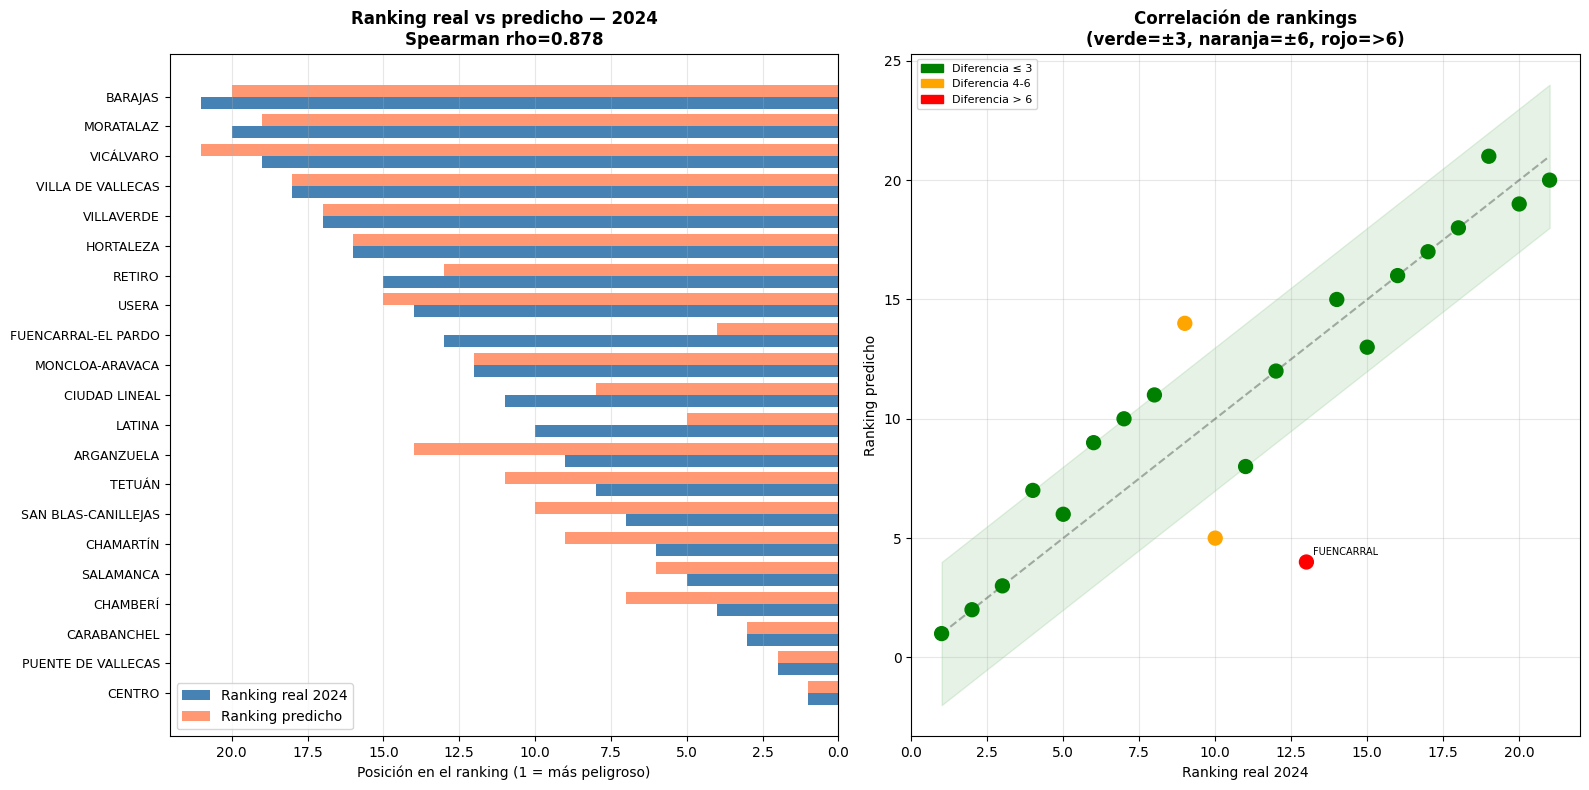

✅ ranking_predicho_vs_real.png guardado


In [ ]:
# GRÁFICO: Ranking predicho vs ranking real
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# ── Izquierda: Ranking comparado lado a lado ──────────────────────────────
ax = axes[0]

rank_real_sorted = rank_comp_l.sort_values('rank_real')
y_pos = np.arange(len(rank_real_sorted))

ax.barh(y_pos - 0.2, rank_real_sorted['rank_real'],
        height=0.4, color='steelblue', label='Ranking real 2024')
ax.barh(y_pos + 0.2, rank_real_sorted['rank_pred'],
        height=0.4, color='coral', alpha=0.8, label='Ranking predicho')

ax.set_yticks(y_pos)
ax.set_yticklabels(rank_real_sorted['distrito'], fontsize=9)
ax.invert_xaxis()
ax.set_xlabel('Posición en el ranking (1 = más peligroso)')
ax.set_title(f'Ranking real vs predicho — 2024\nSpearman rho={rho_largo_rank:.3f}',
             fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

# ── Derecha: Scatter plot ranking real vs predicho ────────────────────────
ax2 = axes[1]

colors = ['green' if d <= 3 else 'orange' if d <= 6 else 'red'
          for d in rank_comp_l['diff']]

ax2.scatter(rank_comp_l['rank_real'], rank_comp_l['rank_pred'],
            c=colors, s=100, zorder=5)

# Línea perfecta
ax2.plot([1, 21], [1, 21], 'k--', alpha=0.3, label='Predicción perfecta')

# Banda de tolerancia ±3
ax2.fill_between([1, 21], [1-3, 21-3], [1+3, 21+3],
                 alpha=0.1, color='green', label='±3 posiciones')

# Etiquetas de distritos problemáticos
for _, row in rank_comp_l.iterrows():
    if row['diff'] > 5:
        ax2.annotate(row['distrito'].split('-')[0],
                    (row['rank_real'], row['rank_pred']),
                    textcoords='offset points', xytext=(5, 5), fontsize=7)

ax2.set_xlabel('Ranking real 2024')
ax2.set_ylabel('Ranking predicho')
ax2.set_title('Correlación de rankings\n(verde=±3, naranja=±6, rojo=>6)',
              fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# Leyenda de colores
verde  = mpatches.Patch(color='green',  label='Diferencia ≤ 3')
naranja= mpatches.Patch(color='orange', label='Diferencia 4-6')
rojo   = mpatches.Patch(color='red',    label='Diferencia > 6')
ax2.legend(handles=[verde, naranja, rojo], fontsize=8)

plt.tight_layout()
plt.savefig(f'{outputs}/ranking_predicho_vs_real.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ ranking_predicho_vs_real.png guardado')

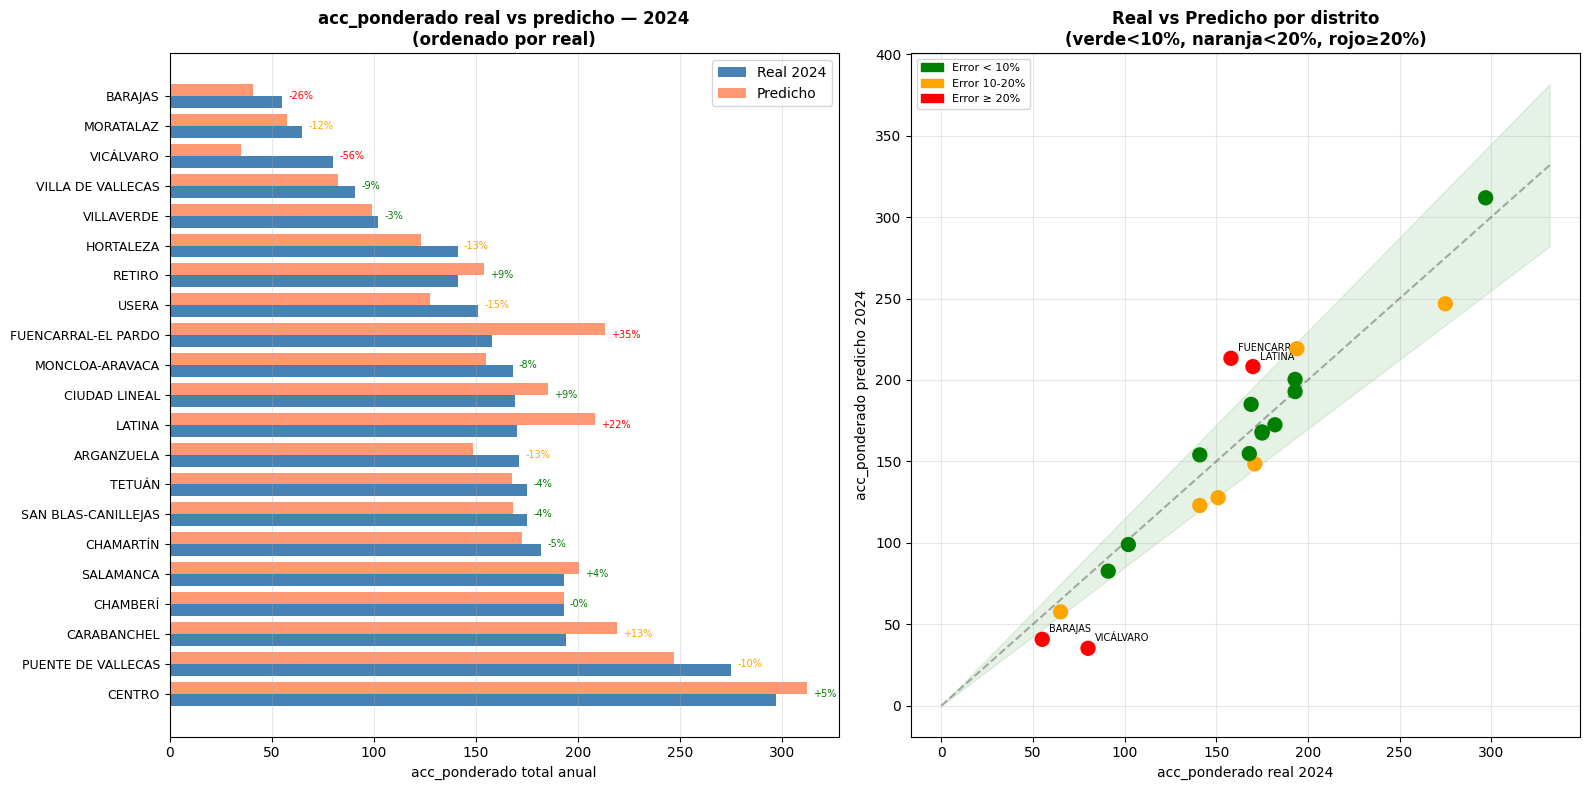

✅ acc_ponderado_real_vs_predicho_2024.png guardado

=== RESUMEN ERRORES ANUALES 2024 ===
Distritos con error < 10%:  11/21
Distritos con error 10-20%: 6/21
Distritos con error ≥ 20%:  4/21

Error porcentual medio:   13.2%
Error porcentual mediano: 9.5%


In [ ]:
# GRÁFICO: acc_ponderado real vs predicho por distrito — 2024

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

distritos_ord = anual_real_largo.sort_values(ascending=False).index.tolist()
real_vals     = [anual_real_largo[d] for d in distritos_ord]
pred_vals     = [anual_pred_largo[d] for d in distritos_ord]
errores_pct   = [(anual_pred_largo[d] - anual_real_largo[d]) / anual_real_largo[d] * 100
                 for d in distritos_ord]

colores_barra = ['green' if abs(e) < 10 else 'orange' if abs(e) < 20 else 'red'
                 for e in errores_pct]

y_pos = np.arange(len(distritos_ord))

# ── Izquierda: barras reales vs predichas ─────────────────────────────────
ax = axes[0]
ax.barh(y_pos - 0.2, real_vals, height=0.4,
        color='steelblue', label='Real 2024')
ax.barh(y_pos + 0.2, pred_vals, height=0.4,
        color='coral', alpha=0.8, label='Predicho')

ax.set_yticks(y_pos)
ax.set_yticklabels(distritos_ord, fontsize=9)
ax.set_xlabel('acc_ponderado total anual')
ax.set_title('acc_ponderado real vs predicho — 2024\n(ordenado por real)',
             fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

# Añadimos el error% encima de cada barra
for i, (r, p, e) in enumerate(zip(real_vals, pred_vals, errores_pct)):
    color = 'green' if abs(e) < 10 else 'orange' if abs(e) < 20 else 'red'
    ax.text(max(r, p) + 3, i, f'{e:+.0f}%', va='center', fontsize=7, color=color)

# ── Derecha: scatter real vs predicho ────────────────────────────────────
ax2 = axes[1]

ax2.scatter(real_vals, pred_vals, c=colores_barra, s=100, zorder=5)

# Línea perfecta
max_val = max(max(real_vals), max(pred_vals)) + 20
ax2.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Predicción perfecta')

# Banda ±15%
x_line = np.array([0, max_val])
ax2.fill_between(x_line, x_line * 0.85, x_line * 1.15,
                 alpha=0.1, color='green', label='±15%')

# Etiquetas de distritos con error > 20%
for i, d in enumerate(distritos_ord):
    if abs(errores_pct[i]) > 20:
        ax2.annotate(d.split('-')[0],
                    (real_vals[i], pred_vals[i]),
                    textcoords='offset points', xytext=(5, 5), fontsize=7)

ax2.set_xlabel('acc_ponderado real 2024')
ax2.set_ylabel('acc_ponderado predicho 2024')
ax2.set_title('Real vs Predicho por distrito\n(verde<10%, naranja<20%, rojo≥20%)',
              fontweight='bold')

verde   = mpatches.Patch(color='green',  label='Error < 10%')
naranja = mpatches.Patch(color='orange', label='Error 10-20%')
rojo    = mpatches.Patch(color='red',    label='Error ≥ 20%')
ax2.legend(handles=[verde, naranja, rojo], fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{outputs}/acc_ponderado_real_vs_predicho_2024.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('✅ acc_ponderado_real_vs_predicho_2024.png guardado')

# Resumen numérico
print('\n=== RESUMEN ERRORES ANUALES 2024 ===')
print(f'Distritos con error < 10%:  {sum(1 for e in errores_pct if abs(e) < 10)}/21')
print(f'Distritos con error 10-20%: {sum(1 for e in errores_pct if 10 <= abs(e) < 20)}/21')
print(f'Distritos con error ≥ 20%:  {sum(1 for e in errores_pct if abs(e) >= 20)}/21')
print(f'\nError porcentual medio:   {np.mean([abs(e) for e in errores_pct]):.1f}%')
print(f'Error porcentual mediano: {np.median([abs(e) for e in errores_pct]):.1f}%')

=== TOP 15 VARIABLES MÁS IMPORTANTES ===
Variable                        Coeficiente  Importancia Tipo
---------------------------------------------------------------------------
dist_CENTRO                         +1.9157       1.9157  Efecto fijo distrito
dist_VIC_LVARO                      -1.6080       1.6080  Efecto fijo distrito
dist_BARAJAS                        -1.5089       1.5089  Efecto fijo distrito
cambio_estructura                   -1.2862       1.2862  Control
dist_MORATALAZ                      -1.2405       1.2405  Efecto fijo distrito
lag_12                              +1.1936       1.1936  Autorregresiva
mes_8                               -1.1470       1.1470  Estacionalidad mensual
dist_PUENTE_DE_VALLECAS             +1.0930       1.0930  Efecto fijo distrito
dist_VILLA_DE_VALLECAS              -0.9384       0.9384  Efecto fijo distrito
dist_CARABANCHEL                    +0.8465       0.8465  Efecto fijo distrito
dist_VILLAVERDE                     -0.7599     

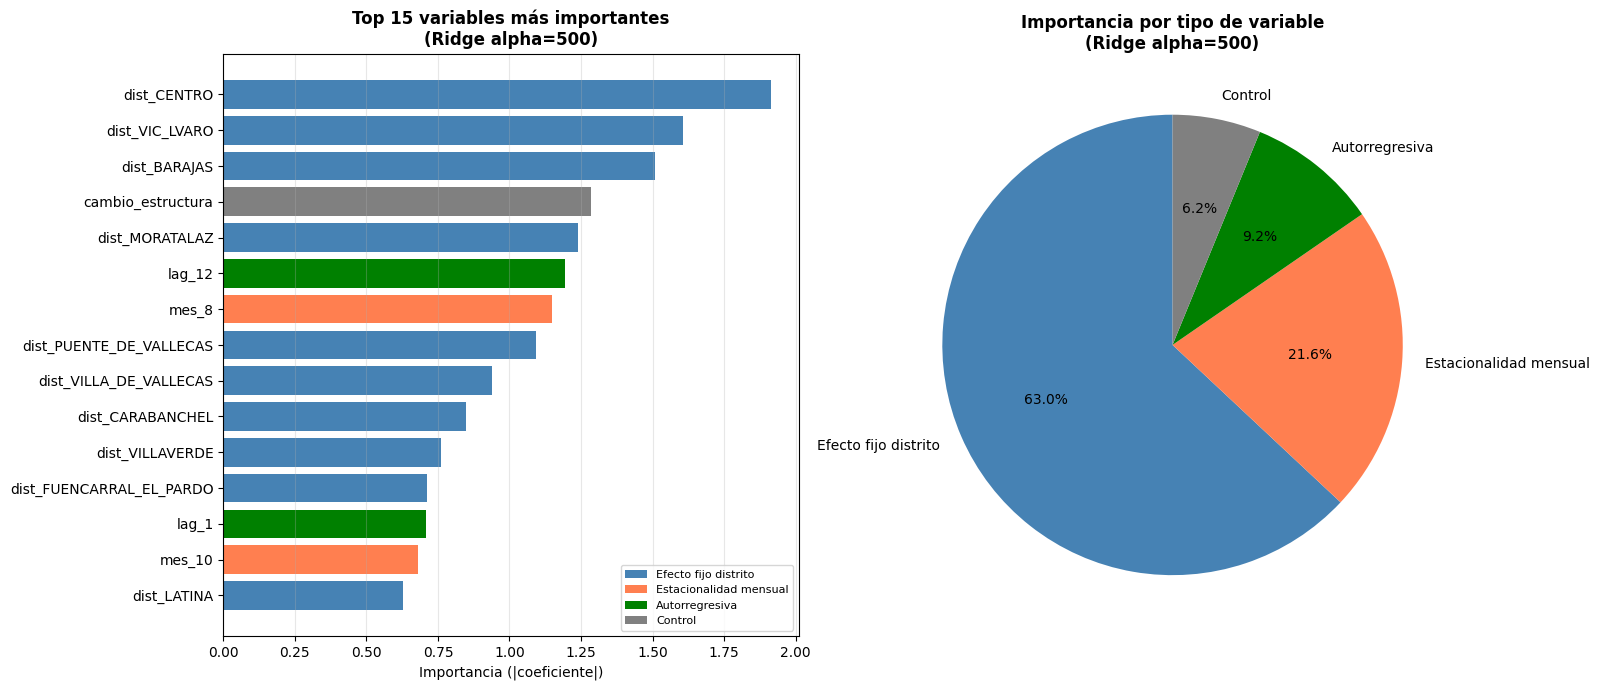

✅ importancia_variables_ridge.png guardado


In [ ]:
# IMPORTANCIA DE VARIABLES EN RIDGE
# En Ridge, la importancia se mide por el valor absoluto del coeficiente
# tras el escalado — variables con coeficiente mayor tienen más peso

import pandas as pd
import matplotlib.pyplot as plt

# Coeficientes del modelo ganador (Ridge largo alpha=500)
coeficientes = pd.DataFrame({
    'variable': feature_cols,
    'coeficiente': ridge_opt.coef_
})

# Valor absoluto para medir importancia
coeficientes['importancia'] = coeficientes['coeficiente'].abs()
coeficientes = coeficientes.sort_values('importancia', ascending=False)

# Separamos por tipo de variable para mejor interpretación
def tipo_variable(nombre):
    if nombre.startswith('dist_'):
        return 'Efecto fijo distrito'
    elif nombre.startswith('mes_'):
        return 'Estacionalidad mensual'
    elif nombre in ['lag_1', 'lag_12', 'tendencia_3m']:
        return 'Autorregresiva'
    else:
        return 'Control'

coeficientes['tipo'] = coeficientes['variable'].apply(tipo_variable)

print('=== TOP 15 VARIABLES MÁS IMPORTANTES ===')
print(f'{"Variable":<30} {"Coeficiente":>12} {"Importancia":>12} {"Tipo"}')
print('-' * 75)
for _, row in coeficientes.head(15).iterrows():
    signo = '+' if row['coeficiente'] > 0 else '-'
    print(f'{row["variable"]:<30} {row["coeficiente"]:>+12.4f} {row["importancia"]:>12.4f}  {row["tipo"]}')

print('\n=== IMPORTANCIA POR TIPO DE VARIABLE ===')
por_tipo = (
    coeficientes.groupby('tipo')['importancia']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)
por_tipo['pct'] = (por_tipo['importancia'] / por_tipo['importancia'].sum() * 100).round(1)
for _, row in por_tipo.iterrows():
    print(f'{row["tipo"]:<30}: {row["pct"]:>5.1f}% de la importancia total')

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Izquierda: top 15 variables ───────────────────────────────────────────
ax = axes[0]
top15 = coeficientes.head(15)
colores_tipo = {
    'Efecto fijo distrito':  'steelblue',
    'Estacionalidad mensual': 'coral',
    'Autorregresiva':         'green',
    'Control':                'gray'
}
colors = [colores_tipo[t] for t in top15['tipo']]
bars = ax.barh(top15['variable'][::-1], top15['importancia'][::-1], color=colors[::-1])
ax.set_xlabel('Importancia (|coeficiente|)')
ax.set_title('Top 15 variables más importantes\n(Ridge alpha=500)', fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colores_tipo.items()]
ax.legend(handles=legend_elements, fontsize=8)
ax.grid(axis='x', alpha=0.3)

# ── Derecha: importancia por tipo ─────────────────────────────────────────
ax2 = axes[1]
colores_pie = [colores_tipo[t] for t in por_tipo['tipo']]
wedges, texts, autotexts = ax2.pie(
    por_tipo['importancia'],
    labels=por_tipo['tipo'],
    autopct='%1.1f%%',
    colors=colores_pie,
    startangle=90
)
ax2.set_title('Importancia por tipo de variable\n(Ridge alpha=500)', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{outputs}/importancia_variables_ridge.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ importancia_variables_ridge.png guardado')

In [ ]:
# ══════════════════════════════════════════════════════════
# CELDA — Walk-Forward Validation + Comparativa de modelos
# Modelos: Naïve, SARIMA, ARIMAX, Ridge, XGBoost
# Métricas: RMSE, MASE, R², Rho ranking anual
# Cortes:
#   Fold 1: Train 2010-2020 → Test 2021
#   Fold 2: Train 2010-2021 → Test 2022
#   Fold 3: Train 2010-2022 → Test 2023
#   Fold 4: Train 2010-2023 → Test 2024
# ══════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model   import Ridge
from sklearn.preprocessing  import StandardScaler
from sklearn.metrics        import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
from scipy.stats            import spearmanr
import xgboost as xgb
import re

# ── Configuración ─────────────────────────────────────────────────────────────
FOLDS = [
    {'train_end': 2020, 'test_year': 2021},
    {'train_end': 2021, 'test_year': 2022},
    {'train_end': 2022, 'test_year': 2023},
    {'train_end': 2023, 'test_year': 2024},
]
no_estacionarios = ['CENTRO', 'FUENCARRAL-EL PARDO', 'TETUÁN']
distritos        = sorted(serie['distrito'].unique())

# ── Helpers ───────────────────────────────────────────────────────────────────
def calcular_metricas(real, pred, naive):
    """RMSE, MASE, R² y MAE a partir de arrays."""
    rmse = np.sqrt(mean_squared_error(real, pred))
    mae  = mean_absolute_error(real, pred)
    mae_naive = mean_absolute_error(real, naive)
    mase = mae / mae_naive if mae_naive > 0 else np.nan
    r2   = r2_score(real, pred)
    return rmse, mase, r2

def calcular_rho_anual(df_fold, col_pred):
    """Rho de Spearman sobre ranking anual agregado."""
    anual = (
        df_fold.groupby('distrito')
        .agg(real=('real', 'sum'), pred=(col_pred, 'sum'))
        .reset_index()
    )
    anual['rank_real'] = anual['real'].rank(ascending=False)
    anual['rank_pred'] = anual['pred'].rank(ascending=False)
    rho, _ = spearmanr(anual['rank_real'], anual['rank_pred'])
    return round(rho, 4)

def naive_prediccion(serie, distrito, año, mes):
    """Predicción naïve: mismo mes del año anterior."""
    val = serie[
        (serie['distrito'] == distrito) &
        (serie['año'] == año - 1) &
        (serie['mes'] == mes)
    ]['acc_ponderado'].values
    return val[0] if len(val) > 0 else np.nan

# ── Resultados por fold ────────────────────────────────────────────────────────
resultados = {m: {'rmse': [], 'mase': [], 'r2': [], 'rho': []}
              for m in ['naive', 'sarima', 'arimax', 'ridge', 'xgboost']}

print('Ejecutando Walk-Forward Validation (4 folds)...')
print('⚠️  SARIMA y ARIMAX pueden tardar varios minutos\n')

for fold_idx, fold in enumerate(FOLDS):
    test_year = fold['test_year']
    print(f'── Fold {fold_idx+1}: Train 2010-{fold["train_end"]} → Test {test_year}')

    train_f = serie[serie['año'] <= fold['train_end']].copy()
    test_f  = serie[serie['año'] == test_year].copy()

    # Añadimos fecha si no existe
    for df in [train_f, test_f]:
        df['fecha'] = pd.to_datetime(
            df['año'].astype(str) + '-' + df['mes'].astype(str).str.zfill(2) + '-01'
        )

    registros_fold = []  # acumulará predicciones de todos los modelos

    for distrito in distritos:
        tr = train_f[train_f['distrito'] == distrito].sort_values('fecha')
        te = test_f[test_f['distrito']  == distrito].sort_values('fecha')
        if len(te) == 0:
            continue

        reales = te['acc_ponderado'].values
        fechas = te['fecha'].values
        meses  = te['mes'].values

        # ── Naïve ──────────────────────────────────────────────────────────
        pred_naive = np.array([
            naive_prediccion(serie, distrito, test_year, m) for m in meses
        ])
        pred_naive = np.where(np.isnan(pred_naive), 0, pred_naive)

        # ── SARIMA ─────────────────────────────────────────────────────────
        try:
            s_train = tr.set_index('fecha')['acc_ponderado']
            d_param = 1 if distrito in no_estacionarios else 0
            mod_s   = SARIMAX(s_train, order=(1, d_param, 1),
                              seasonal_order=(1, 1, 1, 12),
                              enforce_stationarity=False,
                              enforce_invertibility=False)
            res_s      = mod_s.fit(disp=False)
            pred_sarima = np.maximum(res_s.forecast(steps=12).values, 0)
        except Exception:
            pred_sarima = pred_naive.copy()

        # ── ARIMAX ─────────────────────────────────────────────────────────
        try:
            exog_tr   = tr[['cambio_estructura']].values
            exog_te   = te[['cambio_estructura']].values
            mod_ax    = SARIMAX(tr.set_index('fecha')['acc_ponderado'],
                                exog=exog_tr,
                                order=(1, d_param, 1),
                                seasonal_order=(1, 1, 1, 12),
                                enforce_stationarity=False,
                                enforce_invertibility=False)
            res_ax      = mod_ax.fit(disp=False)
            pred_arimax = np.maximum(res_ax.forecast(steps=12, exog=exog_te).values, 0)
        except Exception:
            pred_arimax = pred_naive.copy()

        for i in range(len(reales)):
            registros_fold.append({
                'distrito':     distrito,
                'mes':          meses[i],
                'real':         reales[i],
                'pred_naive':   pred_naive[i],
                'pred_sarima':  pred_sarima[i] if i < len(pred_sarima) else np.nan,
                'pred_arimax':  pred_arimax[i] if i < len(pred_arimax) else np.nan,
            })

    df_fold = pd.DataFrame(registros_fold).dropna()

    # ── Ridge y XGBoost (panel completo) ───────────────────────────────────
    sf      = crear_features_panel(serie[serie['año'] <= test_year].copy())
    tr_p    = sf[sf['año'] <= fold['train_end']].dropna(subset=feature_cols)
    te_p    = sf[sf['año'] == test_year].dropna(subset=feature_cols)

    X_tr = tr_p[feature_cols].values
    y_tr = tr_p['acc_ponderado'].values
    X_te = te_p[feature_cols].values
    y_te = te_p['acc_ponderado'].values

    # Ridge
    sc      = StandardScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)
    ridge_f = Ridge(alpha=500.0)
    ridge_f.fit(X_tr_sc, y_tr)
    pred_ridge = np.maximum(ridge_f.predict(X_te_sc), 0)

    # XGBoost
    xgb_f = xgb.XGBRegressor(
        n_estimators=200, learning_rate=0.05,
        max_depth=4, subsample=0.8,
        colsample_bytree=0.8, random_state=42,
        verbosity=0
    )
    xgb_f.fit(X_tr, y_tr)
    pred_xgb = np.maximum(xgb_f.predict(X_te), 0)

    # Añadimos Ridge y XGBoost al df_fold
    te_p = te_p.copy()
    te_p['pred_ridge']   = pred_ridge
    te_p['pred_xgboost'] = pred_xgb

    df_fold = df_fold.merge(
        te_p[['distrito', 'mes', 'pred_ridge', 'pred_xgboost']],
        on=['distrito', 'mes'], how='left'
    ).dropna()

    # ── Métricas por fold ──────────────────────────────────────────────────
    naive_arr = df_fold['pred_naive'].values
    real_arr  = df_fold['real'].values

    for modelo, col in [('naive',   'pred_naive'),
                         ('sarima',  'pred_sarima'),
                         ('arimax',  'pred_arimax'),
                         ('ridge',   'pred_ridge'),
                         ('xgboost', 'pred_xgboost')]:
        pred_arr            = df_fold[col].values
        rmse, mase, r2      = calcular_metricas(real_arr, pred_arr, naive_arr)
        rho                 = calcular_rho_anual(df_fold, col)
        resultados[modelo]['rmse'].append(rmse)
        resultados[modelo]['mase'].append(mase)
        resultados[modelo]['r2'].append(r2)
        resultados[modelo]['rho'].append(rho)

    print(f'   ✅ Fold {fold_idx+1} completado')

# ── Tabla comparativa final ────────────────────────────────────────────────────
print('\n')
print('╔══════════════════════════════════════════════════════════════════╗')
print('║        COMPARATIVA WALK-FORWARD (media 4 folds)                 ║')
print('╠══════════════════════════════════════════════════════════════════╣')
print(f'║ {"Modelo":<15} {"RMSE":>8} {"MASE":>8} {"R²":>8} {"Rho":>8}       ║')
print('╠══════════════════════════════════════════════════════════════════╣')

resumen = {}
for modelo in ['naive', 'sarima', 'arimax', 'ridge', 'xgboost']:
    r = resultados[modelo]
    rmse = np.mean(r['rmse'])
    mase = np.mean(r['mase'])
    r2   = np.mean(r['r2'])
    rho  = np.mean(r['rho'])
    resumen[modelo] = {'rmse': rmse, 'mase': mase, 'r2': r2, 'rho': rho}
    print(f'║ {modelo:<15} {rmse:>8.3f} {mase:>8.3f} {r2:>8.3f} {rho:>8.3f}       ║')

print('╚══════════════════════════════════════════════════════════════════╝')

# Ganador por métrica
mejor_rmse = min(resumen, key=lambda m: resumen[m]['rmse'])
mejor_mase = min(resumen, key=lambda m: resumen[m]['mase'])
mejor_r2   = max(resumen, key=lambda m: resumen[m]['r2'])
mejor_rho  = max(resumen, key=lambda m: resumen[m]['rho'])

print(f'\n🏆 Mejor RMSE:  {mejor_rmse.upper()} ({resumen[mejor_rmse]["rmse"]:.3f})')
print(f'🏆 Mejor MASE:  {mejor_mase.upper()} ({resumen[mejor_mase]["mase"]:.3f})')
print(f'🏆 Mejor R²:    {mejor_r2.upper()} ({resumen[mejor_r2]["r2"]:.3f})')
print(f'🏆 Mejor Rho:   {mejor_rho.upper()} ({resumen[mejor_rho]["rho"]:.3f})')

# Ganador global: el que gana en más métricas
from collections import Counter
votos = Counter([mejor_rmse, mejor_mase, mejor_r2, mejor_rho])
ganador = votos.most_common(1)[0][0]
print(f'\n✅ MODELO SELECCIONADO: {ganador.upper()} '
      f'(gana en {votos[ganador]}/4 métricas)')

Ejecutando Walk-Forward Validation (4 folds)...
⚠️  SARIMA y ARIMAX pueden tardar varios minutos

── Fold 1: Train 2010-2020 → Test 2021
   ✅ Fold 1 completado
── Fold 2: Train 2010-2021 → Test 2022
   ✅ Fold 2 completado
── Fold 3: Train 2010-2022 → Test 2023
   ✅ Fold 3 completado
── Fold 4: Train 2010-2023 → Test 2024
   ✅ Fold 4 completado


╔══════════════════════════════════════════════════════════════════╗
║        COMPARATIVA WALK-FORWARD (media 4 folds)                 ║
╠══════════════════════════════════════════════════════════════════╣
║ Modelo              RMSE     MASE       R²      Rho       ║
╠══════════════════════════════════════════════════════════════════╣
║ naive              9.880    1.000   -0.281    0.712       ║
║ sarima             8.291    0.909    0.090    0.724       ║
║ arimax             8.115    0.878    0.130    0.757       ║
║ ridge              7.554    0.828    0.247    0.824       ║
║ xgboost            7.679    0.830    0.224    0.832       ║
╚════

In [ ]:
# ══════════════════════════════════════════════════════════
# CELDA IRP — Predicción 2025 y generación del IRP
# Modelo: Ridge global alpha=500 reentrenado con 2010-2024
# Predicción RECURSIVA: cada mes usa el mes anterior predicho
# ══════════════════════════════════════════════════════════

# Reentrenamos con TODOS los datos disponibles (2010-2024)
serie_features_full = crear_features_panel(serie)

train_full = serie_features_full.dropna(subset=feature_cols)
X_full     = train_full[feature_cols].values
y_full     = train_full['acc_ponderado'].values

scaler_full = StandardScaler()
X_full_sc   = scaler_full.fit_transform(X_full)
ridge_final = Ridge(alpha=500.0)
ridge_final.fit(X_full_sc, y_full)

# Diagnóstico overfitting
from sklearn.metrics import mean_squared_error
import numpy as np

y_train_pred = ridge_final.predict(scaler_full.transform(X_full))
rmse_train = np.sqrt(mean_squared_error(y_full, y_train_pred))
rmse_test = 7.554  # valor verificado del walk-forward
print(f'RMSE train: {rmse_train:.3f}')
print(f'RMSE test:  {rmse_test:.3f}')
print(f'Ratio test/train: {rmse_test/rmse_train:.3f}')

# Guardar datos de entrenamiento para bootstrapping
import joblib
joblib.dump(X_full, f'{outputs}/X_full.pkl')
joblib.dump(y_full, f'{outputs}/y_full.pkl')
joblib.dump(feature_cols, f'{outputs}/feature_cols.pkl')
print('✅ X_full, y_full y feature_cols guardados')

print(f'✅ Ridge final reentrenado con {len(X_full)} observaciones (2010-2024)')

predicciones_2025 = []

for distrito in sorted(serie['distrito'].unique()):
    d = serie[serie['distrito'] == distrito].sort_values('fecha')

    # Historial con datos reales hasta dic 2024
    # Se irá ampliando con predicciones conforme avancemos en 2025
    pred_history = dict(zip(
        zip(d['año'], d['mes']),
        d['acc_ponderado']
    ))

    for mes in range(1, 13):

        # ── lag_1: mes anterior ───────────────────────────────────────────
        # Para enero: dic 2024 real
        # Para el resto: mes anterior de 2025 (predicho en iteración anterior)
        if mes == 1:
            lag_1 = pred_history.get((2024, 12), 0)
        else:
            lag_1 = pred_history.get((2025, mes - 1), 0)

        # ── lag_12: mismo mes de 2024 (siempre real) ──────────────────────
        lag_12 = pred_history.get((2024, mes), 0)

        # ── tendencia_3m: pendiente de los 3 meses anteriores reales/pred ─
        if mes == 1:
            ultimos = [pred_history.get((2024, 10), 0),
                       pred_history.get((2024, 11), 0),
                       pred_history.get((2024, 12), 0)]
        elif mes == 2:
            ultimos = [pred_history.get((2024, 11), 0),
                       pred_history.get((2024, 12), 0),
                       pred_history.get((2025,  1), 0)]  # ← ya predicho
        elif mes == 3:
            ultimos = [pred_history.get((2024, 12), 0),
                       pred_history.get((2025,  1), 0),
                       pred_history.get((2025,  2), 0)]  # ← ya predichos
        else:
            ultimos = [pred_history.get((2025, mes - 3), 0),
                       pred_history.get((2025, mes - 2), 0),
                       pred_history.get((2025, mes - 1), 0)]  # ← todos predichos

        tend = np.polyfit([0, 1, 2], ultimos, 1)[0] if len(ultimos) == 3 else 0

        # ── Dummies ───────────────────────────────────────────────────────
        mes_dummies  = {f'mes_{m}': int(mes == m) for m in range(1, 13)}
        dist_dummies = {
            f'dist_{re.sub("[^a-zA-Z0-9]", "_", d2)}': int(d2 == distrito)
            for d2 in sorted(serie['distrito'].unique())
        }

        fila = {
            'distrito':          distrito,
            'año':               2025,
            'mes':               mes,
            'lag_1':             lag_1,
            'lag_12':            lag_12,
            'tendencia_3m':      tend,
            'cambio_estructura': 1,
            'covid_imputado':    0,
            **mes_dummies,
            **dist_dummies
        }

        # ── Predicción del mes ────────────────────────────────────────────
        X_mes    = scaler_full.transform(pd.DataFrame([fila])[feature_cols].values)
        pred_mes = float(np.maximum(ridge_final.predict(X_mes), 0))

        # Guardamos en historial para que los meses siguientes lo usen como lag
        pred_history[(2025, mes)] = pred_mes

        fila['acc_pred_mensual'] = pred_mes
        predicciones_2025.append(fila)

df_2025 = pd.DataFrame(predicciones_2025)

# Verificación: lag_1 de febrero debe ser la predicción de enero, no 0
ene_centro = df_2025[(df_2025['distrito'] == 'CENTRO') & (df_2025['mes'] == 1)]['acc_pred_mensual'].values[0]
feb_lag1   = df_2025[(df_2025['distrito'] == 'CENTRO') & (df_2025['mes'] == 2)]['lag_1'].values[0]
assert abs(ene_centro - feb_lag1) < 0.01, "⚠️ lag_1 de febrero no usa la predicción de enero"
print(f'✅ Recursividad verificada — lag_1(feb) = pred(ene) = {feb_lag1:.2f}')

# ── Suma anual por distrito → IRP ─────────────────────────────────────────
irp_df = (
    df_2025.groupby('distrito')['acc_pred_mensual']
    .sum()
    .reset_index()
    .rename(columns={'acc_pred_mensual': 'acc_pred_2025'})
)
irp_df['acc_pred_2025'] = irp_df['acc_pred_2025'].round(2)

# Normalización 0-100
mn = irp_df['acc_pred_2025'].min()
mx = irp_df['acc_pred_2025'].max()
irp_df['IRP'] = ((irp_df['acc_pred_2025'] - mn) / (mx - mn) * 100).round(2)

irp_df = irp_df.sort_values('IRP', ascending=False).reset_index(drop=True)
irp_df.index += 1

print('\n=== RANKING IRP — PREDICCIÓN 2025 (recursiva) ===')
print(irp_df[['distrito', 'acc_pred_2025', 'IRP']].to_string())

irp_df.to_csv(
    f'{outputs}/IRP_prediccion_2025.csv',
    index=True, index_label='posicion',
    encoding='utf-8-sig'
)
print('\n✅ IRP_prediccion_2025.csv guardado')

RMSE train: 8.472
RMSE test:  7.554
Ratio test/train: 0.892
✅ X_full, y_full y feature_cols guardados
✅ Ridge final reentrenado con 3528 observaciones (2010-2024)
✅ Recursividad verificada — lag_1(feb) = pred(ene) = 24.83

=== RANKING IRP — PREDICCIÓN 2025 (recursiva) ===
               distrito  acc_pred_2025     IRP
1                CENTRO         294.32  100.00
2    PUENTE DE VALLECAS         243.32   78.63
3           CARABANCHEL         210.83   65.01
4   FUENCARRAL-EL PARDO         197.68   59.50
5             SALAMANCA         197.55   59.45
6                LATINA         196.71   59.10
7              CHAMBERÍ         189.74   56.17
8         CIUDAD LINEAL         178.87   51.62
9             CHAMARTÍN         174.92   49.96
10               TETUÁN         168.62   47.32
11  SAN BLAS-CANILLEJAS         167.11   46.69
12      MONCLOA-ARAVACA         160.63   43.98
13           ARGANZUELA         155.47   41.81
14               RETIRO         151.07   39.97
15            HORTALEZ

In [ ]:
# Guardar modelo y scaler para uso en predicción 2026
import joblib
joblib.dump(ridge_final, f'{outputs}/ridge_final.pkl')
joblib.dump(scaler_full, f'{outputs}/scaler_full.pkl')
print('✅ ridge_final.pkl guardado')
print('✅ scaler_full.pkl guardado')

✅ ridge_final.pkl guardado
✅ scaler_full.pkl guardado


In [ ]:
# SCORE FINAL = 0.60 × IPD_norm + 0.40 × IRP_norm

# Cargamos IPD ranking medio 2021-2024
ipd_ranking = pd.read_csv(f'{outputs}/IPD_ranking_medio.csv')
ipd_ranking.columns = ['posicion', 'distrito', 'IPD_medio']

# Normalizamos IPD 0-100
mn_ipd = ipd_ranking['IPD_medio'].min()
mx_ipd = ipd_ranking['IPD_medio'].max()
ipd_ranking['IPD_norm'] = (
    (ipd_ranking['IPD_medio'] - mn_ipd) / (mx_ipd - mn_ipd) * 100
).round(2)

# Cargamos IRP
irp_ranking = pd.read_csv(f'{outputs}/IRP_prediccion_2025.csv')
irp_ranking.columns = ['posicion', 'distrito', 'acc_pred_2025', 'IRP']

# Unimos
score_df = ipd_ranking[['distrito','IPD_medio','IPD_norm']].merge(
    irp_ranking[['distrito','IRP']],
    on='distrito', how='inner'
)

# Score final
score_df['Score_final'] = (
    score_df['IPD_norm'] * 0.60 +
    score_df['IRP']      * 0.40
).round(2)

# Ranking final
score_df = score_df.sort_values('Score_final', ascending=False).reset_index(drop=True)
score_df.index += 1

print('=== RANKING FINAL — SCORE = 0.60×IPD + 0.40×IRP ===')
print(f'{"Pos":<5} {"Distrito":<25} {"IPD_norm":>10} {"IRP":>8} {"Score":>8}')
print('-' * 60)
for pos, row in score_df.iterrows():
    print(f'{pos:<5} {row["distrito"]:<25} {row["IPD_norm"]:>10.2f} {row["IRP"]:>8.2f} {row["Score_final"]:>8.2f}')

# Guardamos
score_df.to_csv(
    f'{outputs}/score_final.csv',
    index=True, index_label='posicion',
    encoding='utf-8-sig'
)
print('\n✅ score_final.csv guardado')

=== RANKING FINAL — SCORE = 0.60×IPD + 0.40×IRP ===
Pos   Distrito                    IPD_norm      IRP    Score
------------------------------------------------------------
1     CENTRO                         82.20   100.00    89.32
2     CHAMBERÍ                      100.00    56.17    82.47
3     SALAMANCA                      87.55    59.45    76.31
4     RETIRO                         92.39    39.97    71.42
5     PUENTE DE VALLECAS             52.86    78.63    63.17
6     CHAMARTÍN                      67.71    49.96    60.61
7     TETUÁN                         69.09    47.32    60.38
8     CIUDAD LINEAL                  66.02    51.62    60.26
9     LATINA                         57.06    59.10    57.88
10    ARGANZUELA                     62.71    41.81    54.35
11    CARABANCHEL                    43.73    65.01    52.24
12    MORATALAZ                      73.95     6.43    46.94
13    MONCLOA-ARAVACA                46.48    43.98    45.48
14    FUENCARRAL-EL PARDO        

In [ ]:
# COMPARACIÓN IRP vs REALIDAD 2025

val_2025 = pd.read_csv(f'{outputs}/validacion_2025.csv')
irp      = pd.read_csv(f'{outputs}/IRP_prediccion_2025.csv')
score    = pd.read_csv(f'{outputs}/score_final.csv')

# Limpiamos columnas duplicadas para este análisis
val_2025 = val_2025[['distrito','acc_vru_total','acc_ponderado']].copy()
val_2025.columns = ['distrito','acc_vru_real_2025','acc_pond_real_2025']

# Unimos todo
comp = score[['posicion','distrito','Score_final']].merge(
    irp[['distrito','acc_pred_2025','IRP']], on='distrito'
).merge(
    val_2025, on='distrito'
)

# Error de predicción
comp['error_abs']   = (comp['acc_pred_2025'] - comp['acc_pond_real_2025']).round(1)
comp['error_pct']   = (comp['error_abs'] / comp['acc_pond_real_2025'] * 100).round(1)

# Ranking real 2025
comp['rank_real_2025'] = comp['acc_pond_real_2025'].rank(ascending=False).astype(int)
comp['rank_pred_2025'] = comp['IRP'].rank(ascending=False).astype(int)
comp['diff_rank']      = (comp['rank_pred_2025'] - comp['rank_real_2025']).abs()

from scipy.stats import spearmanr
rho_2025, p_2025 = spearmanr(comp['rank_real_2025'], comp['rank_pred_2025'])

print('=== VALIDACIÓN EXTERNA — IRP vs REALIDAD 2025 ===')
print(f'{"Pos":<5} {"Distrito":<25} {"Pred":>8} {"Real":>8} {"Error%":>8} {"Rank pred":>10} {"Rank real":>10} {"Diff":>6}')
print('-' * 85)
for _, row in comp.sort_values('posicion').iterrows():
    flag = '✅' if abs(row['error_pct']) < 15 else '⚠️' if abs(row['error_pct']) < 25 else '❌'
    print(f'{int(row["posicion"]):<5} {row["distrito"]:<25} {row["acc_pred_2025"]:>8.0f} {row["acc_pond_real_2025"]:>8.0f} {row["error_pct"]:>7.1f}% {int(row["rank_pred_2025"]):>10} {int(row["rank_real_2025"]):>10} {int(row["diff_rank"]):>6} {flag}')

print(f'\nError porcentual medio:   {comp["error_pct"].abs().mean():.1f}%')
print(f'Error porcentual mediano: {comp["error_pct"].abs().median():.1f}%')
print(f'Correlación Spearman:     rho={rho_2025:.4f} (p={p_2025:.4f})')

if rho_2025 > 0.7:
    print('✅ El IRP valida correctamente el riesgo futuro de los distritos')
elif rho_2025 > 0.5:
    print('⚠️ Validación moderada')
else:
    print('❌ El IRP no valida bien sobre datos reales 2025')

# Guardamos
comp.to_csv(f'{outputs}/validacion_IRP_2025.csv', index=False, encoding='utf-8-sig')
print('\n✅ validacion_IRP_2025.csv guardado')

=== VALIDACIÓN EXTERNA — IRP vs REALIDAD 2025 ===
Pos   Distrito                      Pred     Real   Error%  Rank pred  Rank real   Diff
-------------------------------------------------------------------------------------
1     CENTRO                         294      245    20.1%          1          2      1 ⚠️
2     CHAMBERÍ                       190      202    -6.1%          7          6      1 ✅
3     SALAMANCA                      198      248   -20.3%          5          1      4 ⚠️
4     RETIRO                         151      140     7.9%         14         15      1 ✅
5     PUENTE DE VALLECAS             243      189    28.7%          2          9      7 ❌
6     CHAMARTÍN                      175      160     9.3%          9         13      4 ✅
7     TETUÁN                         169      171    -1.4%         10         11      1 ✅
8     CIUDAD LINEAL                  179      181    -1.2%          8         10      2 ✅
9     LATINA                         197      213    -

In [ ]:
# ¿Por qué Chamberí sube tanto en el score final?

tabla = pd.read_csv(f'{outputs}/tabla_anual_final.csv')

# Variables derivadas que no están en el CSV
tabla['acc_pond_km2']       = tabla['acc_ponderado'] / tabla['area_km2']
tabla['tasa_mortalidad']    = tabla['acc_vru_mortales'] / tabla['poblacion'] * 100_000
tabla['densidad_vulnerable']= (
    tabla['poblacion'] * (tabla['pct_mayores_65'] + tabla['pct_menores_15']) / 100
) / tabla['area_km2']

print('=== DIAGNÓSTICO CHAMBERÍ vs SALAMANCA vs CENTRO ===')
print(f'{"":30} {"CHAMBERÍ":>12} {"SALAMANCA":>12} {"CENTRO":>10}')
print('-' * 65)

# IPD componentes
ipd_full = pd.read_csv(f'{outputs}/IPD_completo.csv')
for var in ['IPD', 'dim_seguridad', 'dim_vulnerabilidad']:
    val_ch = ipd_full[ipd_full['distrito']=='CHAMBERÍ'][var].mean()
    val_sa = ipd_full[ipd_full['distrito']=='SALAMANCA'][var].mean()
    val_ce = ipd_full[ipd_full['distrito']=='CENTRO'][var].mean()
    print(f'{var:<30} {val_ch:>12.2f} {val_sa:>12.2f} {val_ce:>10.2f}')

print()

# Variables brutas
for var in ['acc_pond_km2', 'tasa_mortalidad', 'pct_mayores_65',
            'densidad_vulnerable', 'area_km2', 'poblacion']:
    val_ch = tabla[tabla['distrito']=='CHAMBERÍ'][var].mean()
    val_sa = tabla[tabla['distrito']=='SALAMANCA'][var].mean()
    val_ce = tabla[tabla['distrito']=='CENTRO'][var].mean()
    print(f'{var:<30} {val_ch:>12.3f} {val_sa:>12.3f} {val_ce:>10.3f}')

print()

# Score final
for d in ['CENTRO', 'CHAMBERÍ', 'SALAMANCA']:
    row = score_df[score_df['distrito'] == d].iloc[0]
    print(f'{row["distrito"]:<25} IPD_norm={row["IPD_norm"]:>6.2f}  IRP={row["IRP"]:>6.2f}  Score={row["Score_final"]:>6.2f}')

=== DIAGNÓSTICO CHAMBERÍ vs SALAMANCA vs CENTRO ===
                                   CHAMBERÍ    SALAMANCA     CENTRO
-----------------------------------------------------------------
IPD                                   63.55        56.76      53.83
dim_seguridad                         43.12        34.60      68.39
dim_vulnerabilidad                    88.52        83.84      36.05

acc_pond_km2                         36.752       36.147     51.243
tasa_mortalidad                       0.469        0.227      0.814
pct_mayores_65                       24.185       23.933     15.807
densidad_vulnerable               10197.694     9364.820   6216.815
area_km2                              4.680        5.390      5.230
poblacion                        140135.833   147600.500 142139.667

CENTRO                    IPD_norm= 82.20  IRP=100.00  Score= 89.32
CHAMBERÍ                  IPD_norm=100.00  IRP= 56.17  Score= 82.47
SALAMANCA                 IPD_norm= 87.55  IRP= 59.45  Score= 76